# 061 — MSA vs. IDA collapse fragilities: estimator bias and hypothesis testing

For each case-study structure the collapse fragility has been estimated twice: by
**Multiple-Stripe Analysis** (binomial MLE over 4 stripes of 30 records) and by an
**IDA following FEMA P695** (method-of-moments fit over 22 collapse intensities).
This notebook tests whether the two estimates differ by more than the sampling
noise of the estimators themselves.

The test statistic is the squared Mahalanobis distance of the log-parameter
difference vector $d = [\ln\theta_{MSA} - \ln\theta_{IDA},\; \ln\beta_{MSA} - \ln\beta_{IDA}]$
from the origin, with the reference distribution obtained by parametric
resampling (Iervolino 2022). Both estimators are biased on the log scale, so the
bias of all four is quantified first and removed from the test point before the
test is run — the IDA dispersion analytically, the MSA dispersion by bootstrap.

All functions live in `phd_project.scripts.msa_ida_hypothesis_testing`; this
notebook is the driver.

## Upstream / downstream

**Upstream** — must have run first:

| Notebook | Provides |
|---|---|
| `060-site_msa_fragility_processing` | `{tag}_msa_collapsefragility_AvgSA_03.json` |
| `014-convert-ida-femap695-site-fragilities-to-avgsa` | `{tag}_ida_femap695_collapsefragility_AvgSA_03.json` |
| `004-psha_results` | `AvgSA_03_hazard_curves_60sites_4sig.pickle` |

**Downstream** — written to `<wp1_sites_fragility_curves>/msa_ida_fema_comparison/`:

| File | Contents |
|---|---|
| `msa_idafema_bias_data.pickle` | `dict[estimator] -> DataFrame` of per-site estimator bias |
| `summary_stats.pickle` | one row per structure: verdict, test distance, ASL, $\Gamma$ |
| `bootstrap_stats.csv` | distribution summaries of every bootstrapped quantity |
| `{tag}_chart1_hypothesis_test.jpg`, `{tag}_chart2_risk_metrics.jpg` | per-structure charts |

## 0. Setup & parameters

In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
import json
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import lognorm

from standes.intensitymeasures import AverageSpectralAcceleration
from hazrisk.risk import numerical_mafe
from phd_project.config import config
from phd_project.scripts import msa_ida_hypothesis_testing as mih

cfg = config.load_config()

In [41]:
# --- FOLDERS ---
FRAG_ROOT = cfg["proc_data"]["wp1_sites_fragility_curves"]
HAZ_CURVE_PATH = cfg["proc_data"]["AvgSA_03_hazard_curves_4sig"]
DISAGG_STATS_PATH = cfg["proc_data"]["AvgSA_03_disagg_stats_gm_selection"]
OUT_FOLDER = FRAG_ROOT / "msa_ida_fema_comparison"
OUT_FOLDER.mkdir(parents=True, exist_ok=True)

# --- STRUCTURES ---
SITES = list(range(0, 60))
N_STOREYS = [3]
IM = AverageSpectralAcceleration(0, 3, n_periods=10)

# --- ANALYSIS SIZES ---
N_STRIPE_RECS = 30      # records per MSA stripe
N_IDA_RECS = 22         # records in the FEMA P695 IDA

# --- BIAS ASSESSMENT ---
# B sets the Monte Carlo error on the bias: mcse/se = 1/sqrt(B), so B = 5000
# gives 1.4%, and mcse ~ 0.27 of the real between-site spread of the MSA bias.
FORCE_BIAS_RECALCULATION = False
B = 5_000

# --- HYPOTHESIS TEST ---
FORCE_HYPOTEST__RECALCULATION = False
K_SAMPLES = 1000        # parametric bootstrap replicates per arm
ALPHA = 0.05            # significance level
EC8_TARGET = 2e-4       # EC8 target mean annual frequency of collapse

## 1. Load hazard and fragility curves

`hcs[site]["AvgSA"]["mean"]` is an `(n_iml, 2)` array of `[iml, mafe]`. A structure
is only kept when *both* fragility arms are present, so the two arms are always
paired; sites 24, 31 and 38 have no MSA result and drop out here.

In [ ]:
with open(HAZ_CURVE_PATH, "rb") as file:
    hcs = pickle.load(file)

In [43]:
fragility_curves, fragility_curves_flat = mih.load_site_fragility_curves(
    FRAG_ROOT, SITES, N_STOREYS)

print(f"loaded {len(fragility_curves_flat['msa'])} structures with msa")
print(f"loaded {len(fragility_curves_flat['ida-femap695'])} structures with ida")

No Fragility Curve for msa: site 24 and 3s. Skipping...
No Fragility Curve for msa: site 31 and 3s. Skipping...
No Fragility Curve for msa: site 38 and 3s. Skipping...
loaded 57 structures with msa
loaded 60 structures with ida


In [44]:
# the disaggregation summary, which also carries each site's seismicity band
with open(DISAGG_STATS_PATH, "rb") as file:
    disagg_stats = pickle.load(file)
disagg_stats = disagg_stats.set_index(["site_id", "imtl"])


## 2. Estimator bias

There is uncertainty associated with the analysis method and the subsequent
fitting of the fragility curves. To decide whether the differences between the
IDA- and MSA-derived curves are significant we compare the distributions of the
median and dispersion, obtained by parametric resampling as described by
Iervolino (2022), *"Estimation uncertainty for some common seismic fragility curve
fitting methods"*.

The test statistic is built from $\ln\theta$ and $\ln\beta$, and both are
**biased** estimators even where $\theta$ and $\beta$ are not — the log is
concave, and for IDA the dispersion also passes through a square root. That bias
sits directly on the test point, so it is quantified here and removed before any
hypothesis is tested.

Two ratios decide what to do with each bias:

- $|b| / se$ against **0.25** — is the bias material next to the estimator's own
  spread? Below 0.25 the RMSE penalty is under 3.1% (Efron & Tibshirani, p.128).
- $|b| / mcse$ against **2** — has the bias been *resolved* from its own Monte
  Carlo error, or is it indistinguishable from simulation noise?

### 2.1 Bootstrap the bias

Slow: `B` x 2 arms x 57 structures refits. Skip to 2.2 to reload the cached result.

In [45]:
if FORCE_BIAS_RECALCULATION:
    bias_data = mih.compute_bias_data(
        fragility_curves, N_STOREYS, B, N_IDA_RECS, N_STRIPE_RECS)

    with open(OUT_FOLDER / "msa_idafema_bias_data.pickle", "wb") as file:
        pickle.dump(bias_data, file)
else:
    print("Skipping bias calculation because 'FORCE_BIAS_RECALCULATION == False'")

Skipping bias calculation because 'FORCE_BIAS_RECALCULATION == False'


### 2.2 Reload the cached bias data

In [46]:
with open(OUT_FOLDER / "msa_idafema_bias_data.pickle", "rb") as file:
    bias_data = pickle.load(file)

### 2.3 Bias corrections and diagnostics

$\ln\theta$ is left uncorrected in both arms — its bias is immaterial against
the estimator's own standard error. $\ln\beta$ is corrected in both:

- **IDA** by the closed form $\tfrac{1}{2}[\psi(\tfrac{n-1}{2}) - \ln\tfrac{n-1}{2}] = -0.0242$
  at $n = 22$. It is a deterministic function of the record count containing no
  data, so it is identical at every site and costs no variance.
- **MSA** by that site's *own* bootstrap estimate, because the MSA bias has no
  closed form and varies genuinely between sites with the stripe placement
  (section 3). The MSA residual is therefore zero by construction; the IDA
  residual is a real test of the analytic result, and it lands within
  ~1 MCSE of zero.

BIAS / SE ratios for test statistic (msa-ida) averaged over the sites:
Theta 0.10357291772851791
Beta 0.6282333127491003
Beta_corrected 0.010851703950101833


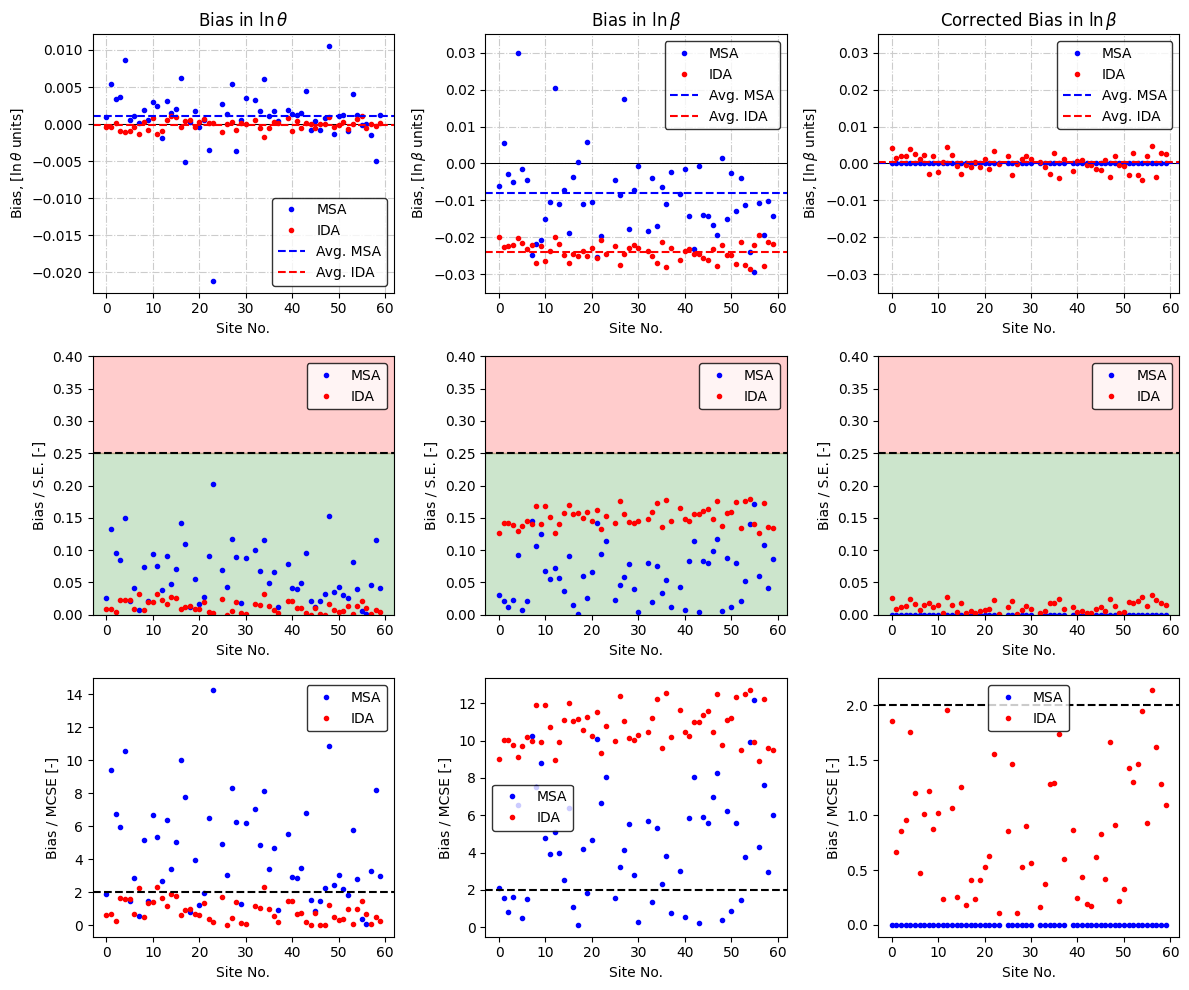

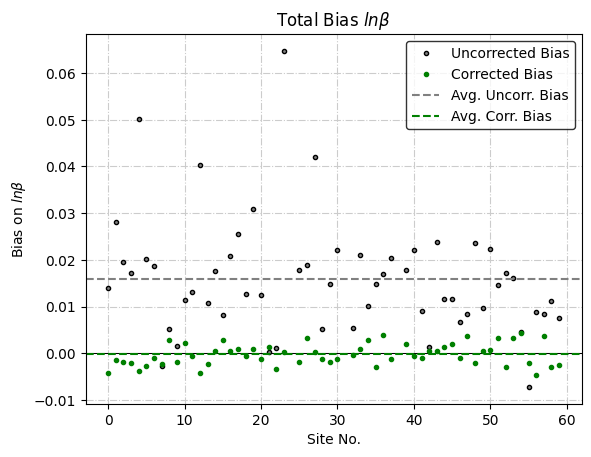

In [47]:
estimator_df = mih.build_estimator_frame(fragility_curves_flat)
total_bias_corrections = mih.apply_bias_corrections(bias_data, N_IDA_RECS)

fig1, axs1, fig2, axs2 = mih.plot_bias_assessment(bias_data, estimator_df)

## 3. Stripe placement and the MSA dispersion bias

The MSA $\ln\beta$ bias varies significantly between sites. It decomposes exactly
into the **raw-scale bias** from the MLE fit (does it centre on the right
dispersion, in $\beta$ units?) and the **Jensen gap** from the log transform
(what taking a log does to a spread-out estimate, always $\le 0$).

Both are driven by how well the stripes constrain $\beta$. The Fisher information
$\sum_j n[\varphi(z_j)z_j]^2 / p_j(1-p_j)$ *vanishes* for a stripe at the median,
so information about the dispersion comes from stripes out in the tails: sites
whose stripes span a wide range of collapse probability estimate $\beta$
precisely, and sites whose stripes cluster centrally do not.

corr(bias, p_range)   = -0.696
corr(bias, se_pred)   = +0.767
corr(bias, n_central) = +0.612
corr(se_pred, se_boot)= +0.777   (validates the placement -> precision link)

se_pred mean 0.1768 vs se_boot mean 0.2075  (-14.8%)

decomposition (means): raw-scale +0.01491  +  Jensen -0.02227  =  -0.00736   (actual bias -0.00812)
corr(raw_scale, p_range) = -0.792   corr(jensen, p_range) = +0.863


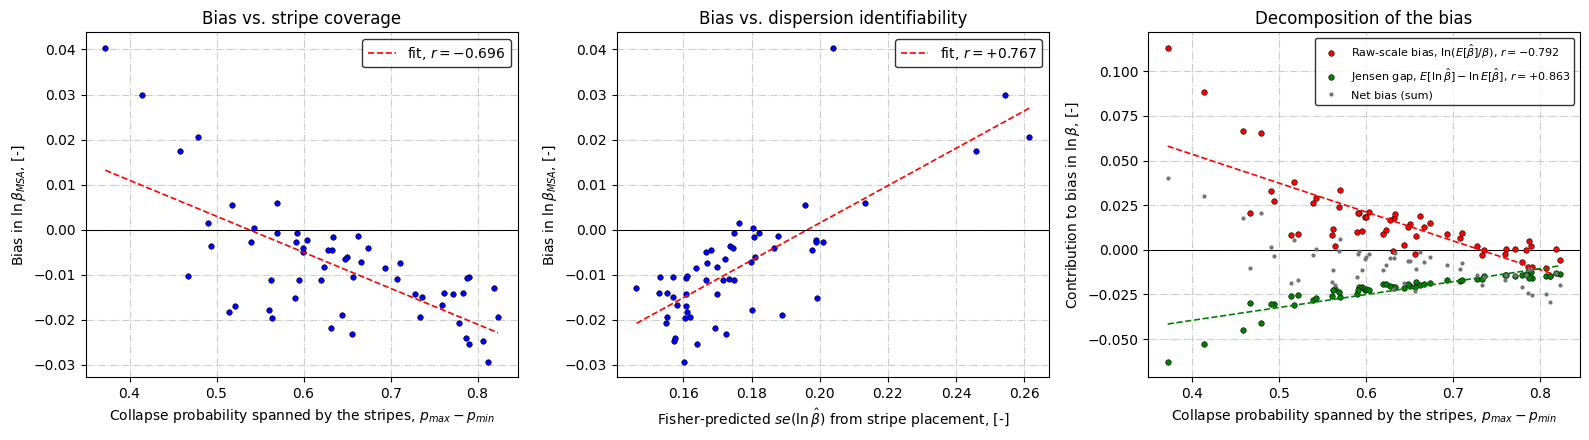

In [48]:
fig_cov, axs_cov, stripe_coverage = mih.plot_bias_vs_stripe_coverage(
    bias_data, fragility_curves_flat, N_STRIPE_RECS)

In [49]:
# the least informative stripe placements
stripe_coverage.sort_values("se_pred", ascending=False).head(8)

,p_min,p_max,p_range,n_central,se_pred,bias,se_boot,raw_scale,jensen
3s_cbf_dc2_site12,0.309349,0.788249,0.478900,4,0.261487,0.020572,0.286443,0.065259,-0.041025
3s_cbf_dc2_site4,0.192511,0.606671,0.414159,3,0.254384,0.029950,0.324031,0.088349,-0.052498
3s_cbf_dc2_site27,0.185733,0.643976,0.458243,3,0.245835,0.017563,0.298912,0.066269,-0.044674
3s_cbf_dc2_site19,0.154538,0.724175,0.569636,3,0.213160,0.005889,0.228813,0.033282,-0.026178
3s_cbf_dc2_site23,0.477643,0.849759,0.372115,3,0.203848,0.040326,0.354227,0.113003,-0.062738
3s_cbf_dc2_site2,0.111917,0.651547,0.539630,3,0.201064,-0.002719,0.237206,0.026457,-0.028133
3s_cbf_dc2_site10,0.069934,0.660169,0.590236,3,0.199095,-0.015124,0.222846,0.010066,-0.024830
3s_cbf_dc2_site37,0.181081,0.784527,0.603445,3,0.198950,-0.002367,0.211689,0.020894,-0.022406


## 4. Hypothesis test per structure

For each structure both arms are resampled `K_SAMPLES` times, the difference
cloud gives $\Gamma$ and the reference distribution of $D^2_M$, and the
bias-corrected observed difference is tested against its $1-\alpha$ quantile.
Equivalently: the confidence region is centred on the corrected estimate and the
null is rejected when the origin falls outside it.

Two charts are written per structure — the fragility/parameter/test panel and the
risk-metric panel.

In [50]:
if FORCE_HYPOTEST__RECALCULATION:
    bootstrap_stats, summary_stats = mih.run_hypothesis_tests(
        OUT_FOLDER, fragility_curves, hcs, N_STOREYS, total_bias_corrections, IM,
        N_STRIPE_RECS, N_IDA_RECS, K_SAMPLES, alpha=ALPHA, ec8_target=EC8_TARGET)

    n_diff = int(summary_stats["statistically_different"].sum())
    print(f"{n_diff} of {len(summary_stats)} structures differ significantly "
        f"at alpha = {ALPHA}")

    with open(OUT_FOLDER / "summary_stats.pickle", "wb") as file:
        pickle.dump(summary_stats, file)

    bootstrap_stats.to_csv(OUT_FOLDER / "bootstrap_stats.csv")

else:

    with open(OUT_FOLDER / "summary_stats.pickle", "rb") as file:
        summary_stats = pickle.load(file)
    bootstrap_stats = pd.read_csv(OUT_FOLDER / "bootstrap_stats.csv", header=[0, 1], index_col=0)

In [51]:
summary_stats

,statistically_different,rho_msa,rho_ida,msa_pt_estimate,ida_pt_estimate,d_orig,d_corr,d_bar,covar,test_distance,CI_distance,achieved_sig_level
3s_cbf_dc2_site0,False,0.420766,0.001236,"[0.41652975189068964, 0.24920466837007527]","[0.3931420206240298, 0.21623693178476358]","[0.05778696994409638, 0.14189980723225526]","[0.05778696994409638, 0.12371753786342565]","[0.06189307964738421, 0.16586977208763115]","[[0.0033765703633031963, 0.0032898876660812718...",1.054036,5.867908,0.582000
3s_cbf_dc2_site1,False,0.605526,0.052272,"[0.4194104766668332, 0.23589524313898438]","[0.3819996601210207, 0.1904015439992485]","[0.0934303794159318, 0.21425258991105922]","[0.0934303794159318, 0.1846446460830895]","[0.10007694539036163, 0.23578427193972115]","[[0.003376804802574091, 0.005779560148492739],...",2.593183,5.982174,0.270000
3s_cbf_dc2_site2,False,0.520150,-0.023006,"[0.4111085715584963, 0.23206691906003915]","[0.3819996601210207, 0.1904015439992485]","[0.07343762511624119, 0.1978905427344435]","[0.07343762511624119, 0.17642274181972506]","[0.07949557464838174, 0.2269744229534599]","[[0.002719744811440105, 0.003176141348082596],...",2.082752,6.366739,0.324000
3s_cbf_dc2_site3,True,0.612494,-0.027134,"[0.4476548054127432, 0.2508578844879594]","[0.3825272841732061, 0.18886796568351774]","[0.157222429882381, 0.28383840486060063]","[0.157222429882381, 0.26454791551514]","[0.16004339898617603, 0.2983954751603386]","[[0.0034784378357633075, 0.004056750904175911]...",7.210758,5.932640,0.029000
3s_cbf_dc2_site4,False,0.749538,0.051705,"[0.4118739782806762, 0.3270999325159938]","[0.3931420206240298, 0.21623693178476358]","[0.04654650237732061, 0.41389101530145833]","[0.04654650237732061, 0.359754291436188]","[0.06203226295394877, 0.49671542073423364]","[[0.006270347654587376, 0.014727699425012853],...",0.910690,5.692694,0.585170
3s_cbf_dc2_site5,False,0.165839,-0.059416,"[0.3890655021635261, 0.1899290837906299]","[0.3819996601210207, 0.1904015439992485]","[0.018327996596968155, -0.0024844722834436173]","[0.018327996596968155, -0.02522991490472104]","[0.02030286723204687, 0.02216612322978373]","[[0.0022000506782508264, 0.0004328973463966291...",0.165807,6.245417,0.922000
3s_cbf_dc2_site6,False,0.197820,-0.025420,"[0.3833980514540617, 0.2052197388932107]","[0.3819996601210207, 0.1904015439992485]","[0.003654029448555196, 0.07494607054288616]","[0.003654029448555196, 0.05526125639573798]","[0.006635324417543138, 0.10155667873230577]","[[0.0023309431996365636, 0.0007172538372836576...",0.045132,6.017898,0.980000
3s_cbf_dc2_site7,False,0.281285,-0.005052,"[0.47376450588268665, 0.16309123853668908]","[0.46623040775284913, 0.19081191701363567]","[0.016030426035609557, -0.1569784253750277]","[0.016030426035609557, -0.15646862778920378]","[0.01874521756332636, -0.16098884271796116]","[[0.002292943869572416, 0.0013771021301904026]...",0.642870,6.240642,0.720000
3s_cbf_dc2_site8,False,0.525700,0.033712,"[0.42485877426100915, 0.15005132879781663]","[0.3931420206240298, 0.21623693178476358]","[0.07758589562298857, -0.36539728538546723]","[0.07758589562298857, -0.3677699668110135]","[0.0796134856502303, -0.3767868892938978]","[[0.002655579481320723, 0.002396598749077468],...",5.631321,5.866222,0.062000
3s_cbf_dc2_site9,False,0.165597,0.010615,"[0.38714006107581167, 0.1686721278870884]","[0.3601987280197424, 0.18211704222158842]","[0.0721306410599808, -0.07669281064081934]","[0.0721306410599808, -0.08009874604257972]","[0.07725172895855456, -0.07431878226909835]","[[0.0020047195250854043, 0.0010674945317507587...",2.875227,5.849333,0.244000


In [52]:
print("Sites showing a 'statistical' difference between MSA and IDA")
for tag in summary_stats[summary_stats["statistically_different"]].index:
    print(tag)

Sites showing a 'statistical' difference between MSA and IDA
3s_cbf_dc2_site3
3s_cbf_dc2_site15
3s_cbf_dc2_site22
3s_cbf_dc2_site28
3s_cbf_dc2_site55
3s_cbf_dc2_site58


## 5. Site-to-site comparison of fragility curves

### 5.1 Fragility Curves

Text(0.5, 0, 'Normalised Intensity')

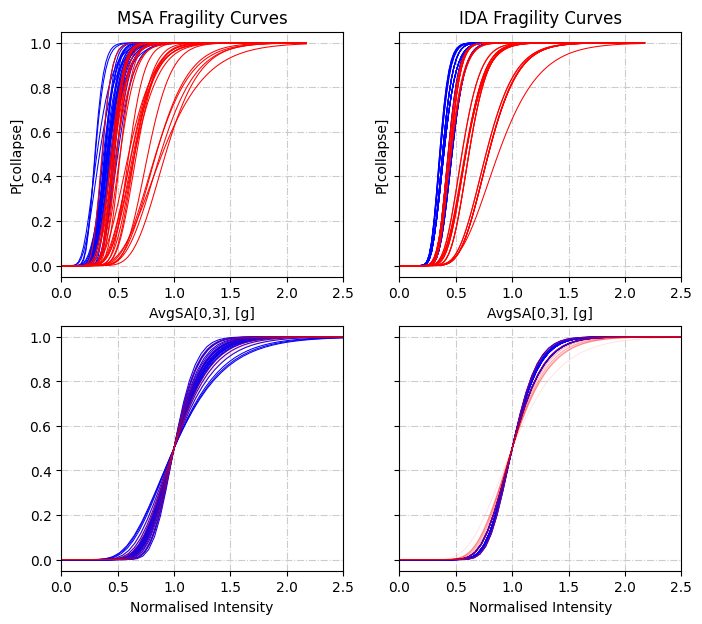

In [53]:
msa_fragility_curves = fragility_curves_flat["msa"]
ida_fragility_curves = fragility_curves_flat["ida-femap695"]

iml_max = np.max([lognorm.ppf(0.995, s=fc["dispersion"], scale=fc["median"]) for fc in msa_fragility_curves.values()])
imls = np.linspace(0, iml_max, 100)

msa_pcs = {tag: lognorm.cdf(imls, s=fc["dispersion"], scale=fc["median"]) for tag,fc in msa_fragility_curves.items()}
ida_pcs = {tag: lognorm.cdf(imls, s=fc["dispersion"], scale=fc["median"]) for tag,fc in ida_fragility_curves.items()}

fig, axs = plt.subplots(2, 2, figsize=(8, 7), sharey=True)

for tag, pc in msa_pcs.items():
    fc_color="r" if int(tag.split("site")[1]) >= 30 else "b"
    fc_alpha=0.1 if int(tag.split("site")[1]) >= 30 else 1.0
    axs[0, 0].plot(imls, pc, color=fc_color, lw=0.75)
    axs[1, 0].plot(imls / msa_fragility_curves[tag]["median"], pc, color=fc_color, lw=0.75, alpha=fc_alpha)

for tag, pc in ida_pcs.items():
    fc_color="r" if int(tag.split("site")[1]) >= 30 else "b"
    fc_alpha=0.1 if int(tag.split("site")[1]) >= 30 else 1.0
    axs[0, 1].plot(imls, pc, color=fc_color, lw=0.75)
    axs[1, 1].plot(imls / ida_fragility_curves[tag]["median"], pc, color=fc_color, lw=0.75, alpha=fc_alpha)

axs[0,0].set_title("MSA Fragility Curves")
axs[0,0].grid(ls="-.", color="0.8")
axs[0,0].set_xlabel("AvgSA[0,3], [g]")
axs[0,0].set_ylabel("P[collapse]")
axs[0,0].set_xlim(0, 2.5)

axs[1,0].grid(ls="-.", color="0.8")
axs[1,0].set_xlim(0, 2.5)
axs[1,0].set_xlabel("Normalised Intensity")

axs[0,1].set_title("IDA Fragility Curves")
axs[0,1].grid(ls="-.", color="0.8")
axs[0,1].set_xlabel("AvgSA[0,3], [g]")
axs[0,1].set_ylabel("P[collapse]")
axs[0,1].set_xlim(0, 2.5)

axs[1,1].grid(ls="-.", color="0.8")
axs[1,1].set_xlim(0, 2.5)
axs[1,1].set_xlabel("Normalised Intensity")

### 5.2 Site-to-site comparison of the bootstrap statistics

Cross-site bar charts of the quantities in `bootstrap_stats`. Each bar is the
bootstrap **median** and the whiskers span the **5-95%** interval. Quantities that
have both an MSA and an IDA variant are drawn side by side, MSA in blue and IDA in
red; the ratios already contain both arms and are drawn in green.

Sites 0-29 (low/moderate seismicity) are on the upper axis and sites 30-59 (high
seismicity) on the lower one, on a shared y-scale. Sites without a usable MSA fit
(24, 31, 38) leave a gap. The six regional groupings of five sites are shaded
alternately and labelled `R0`-`R5`.

The two risk metrics use a log y-axis because they run over orders of magnitude
between the two seismicity bands.

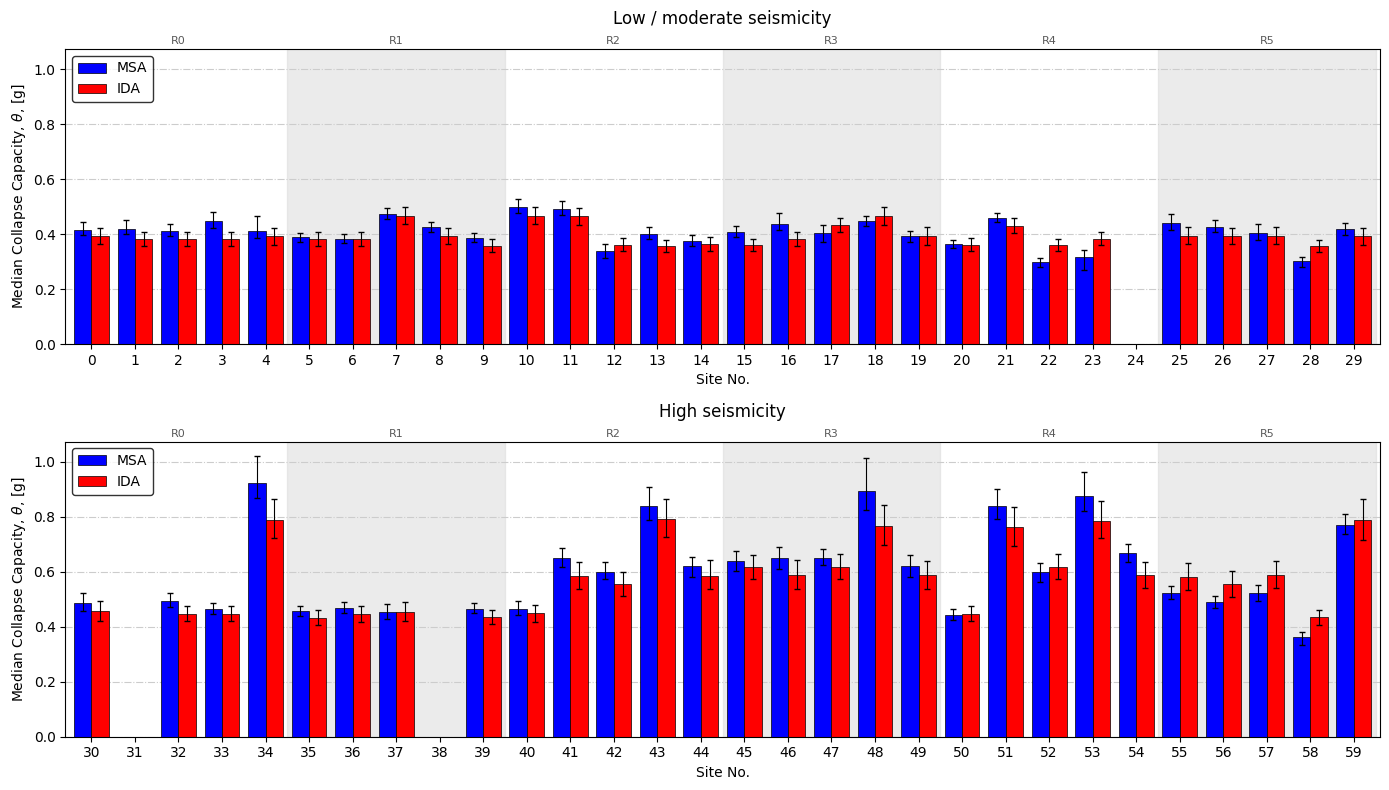

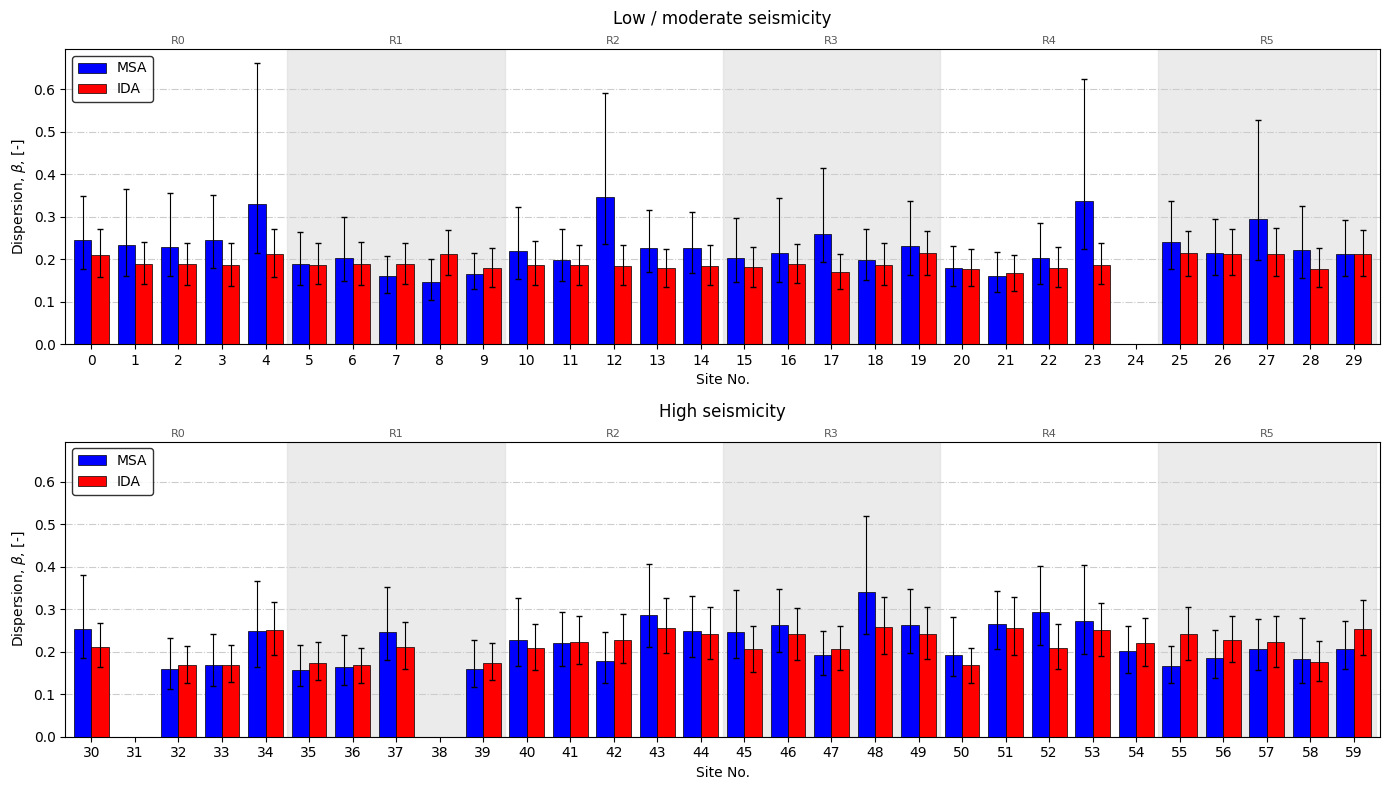

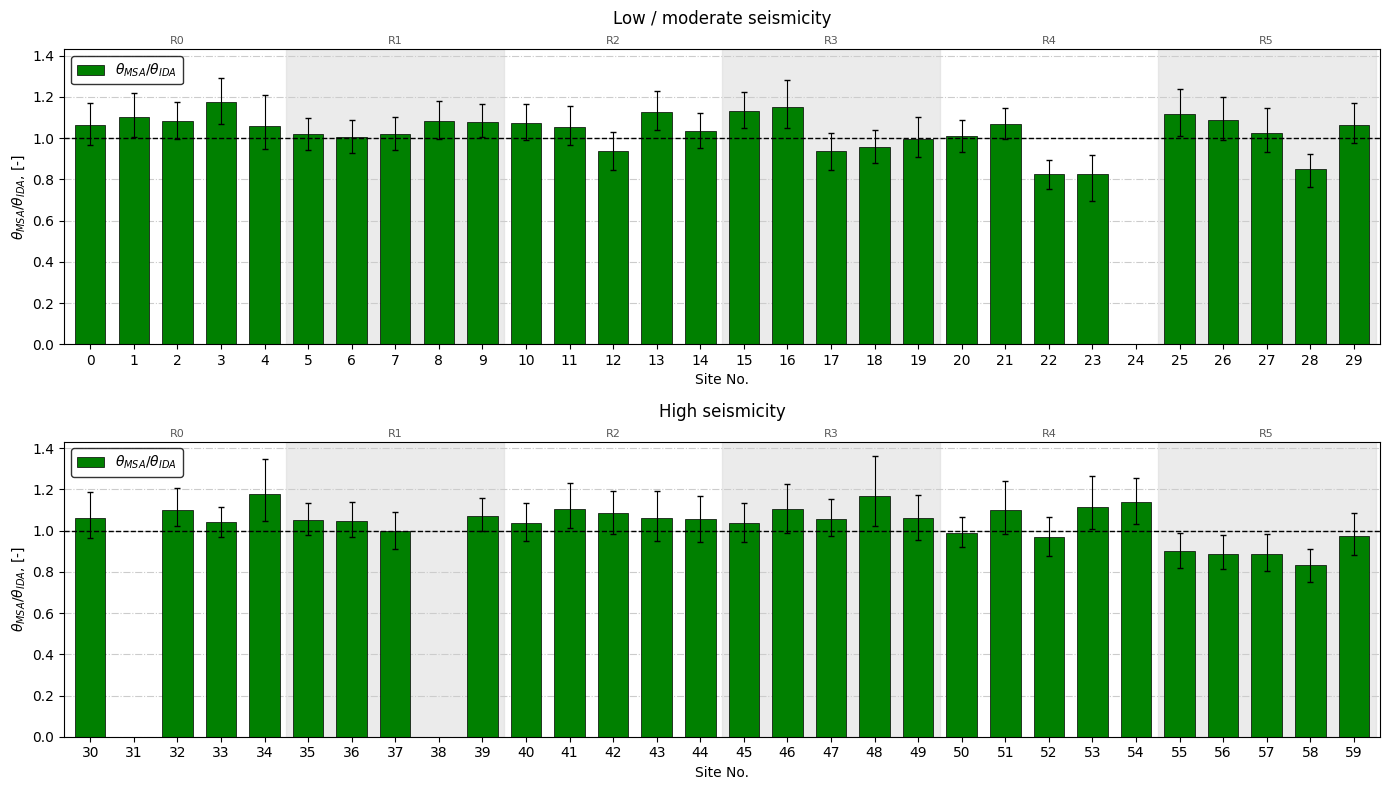

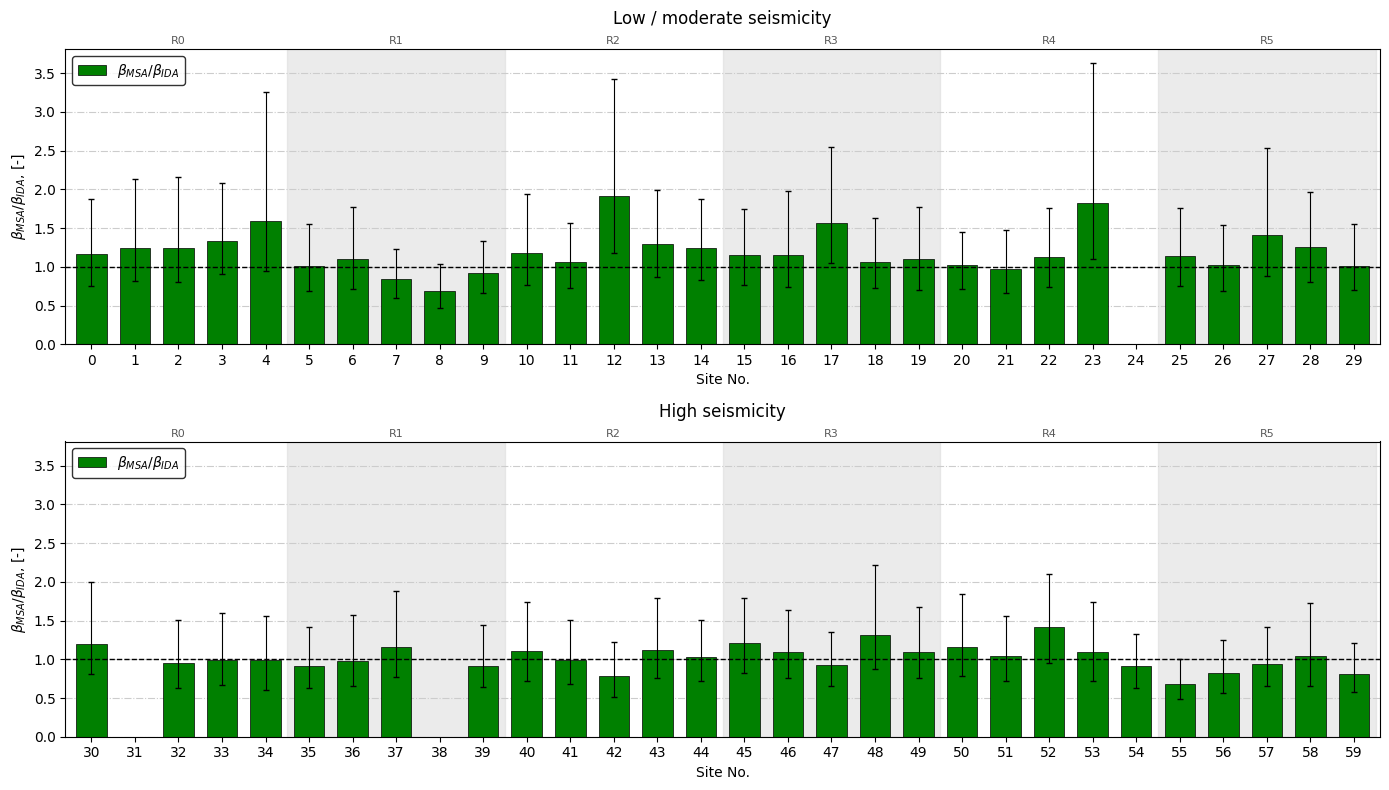

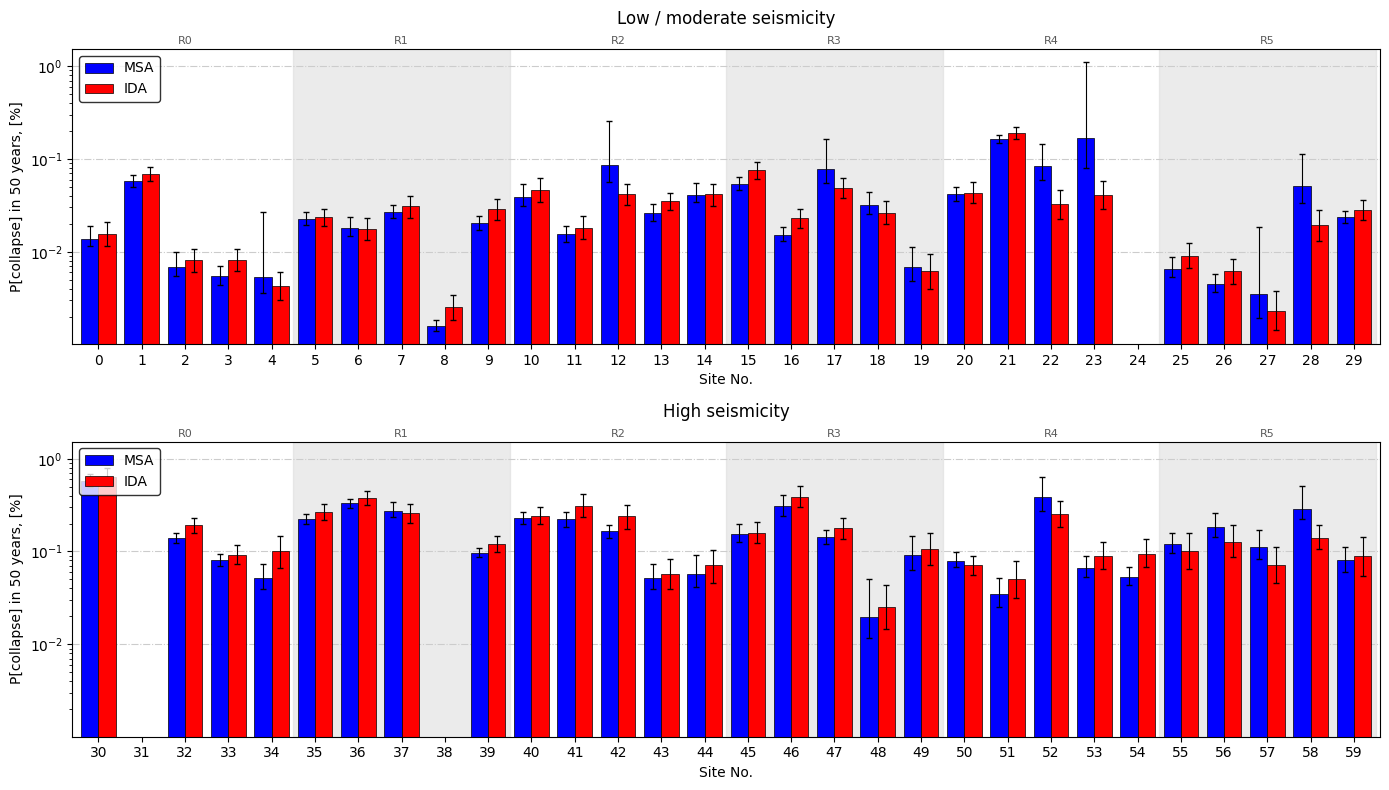

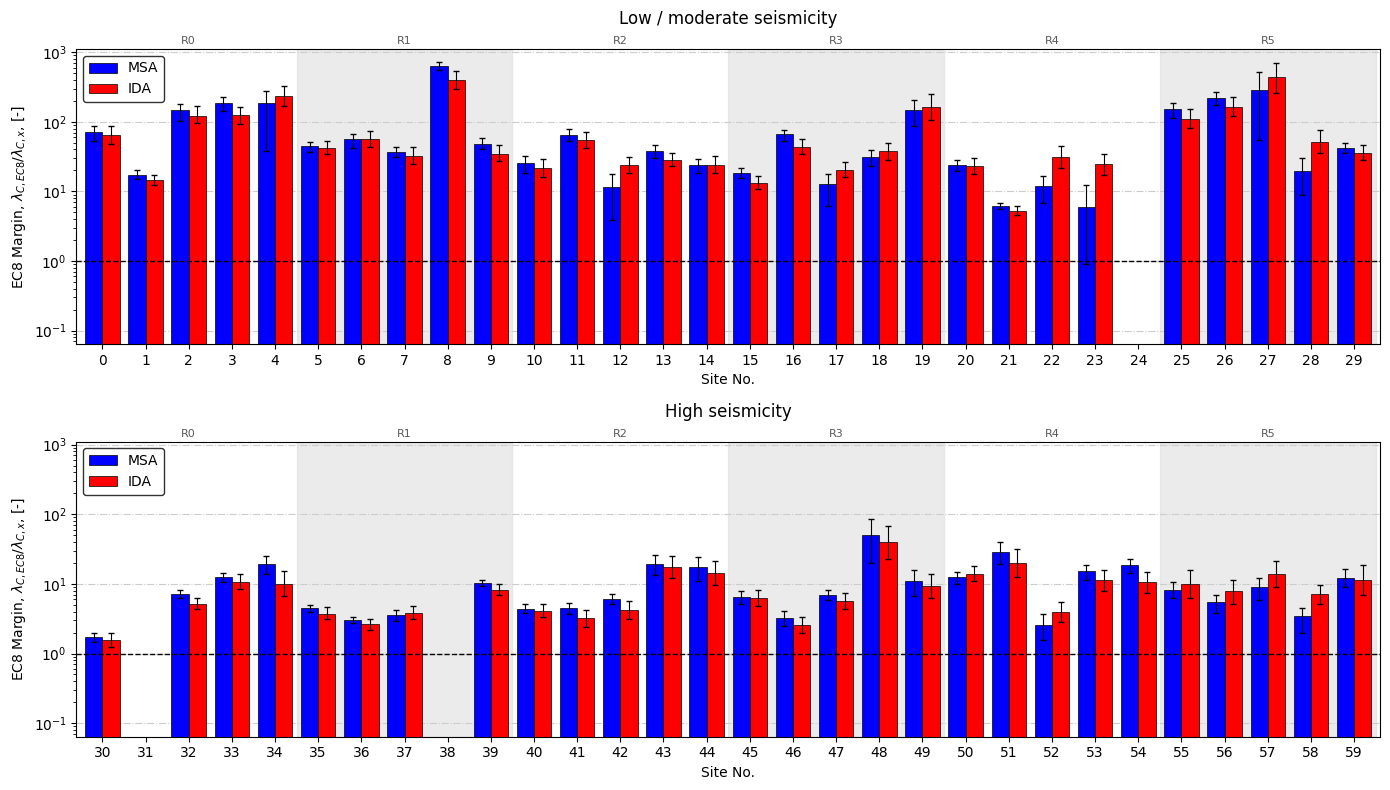

In [54]:
site_figs = mih.plot_site_statistic_summary(
    bootstrap_stats, t=50, out_folder=OUT_FOLDER)

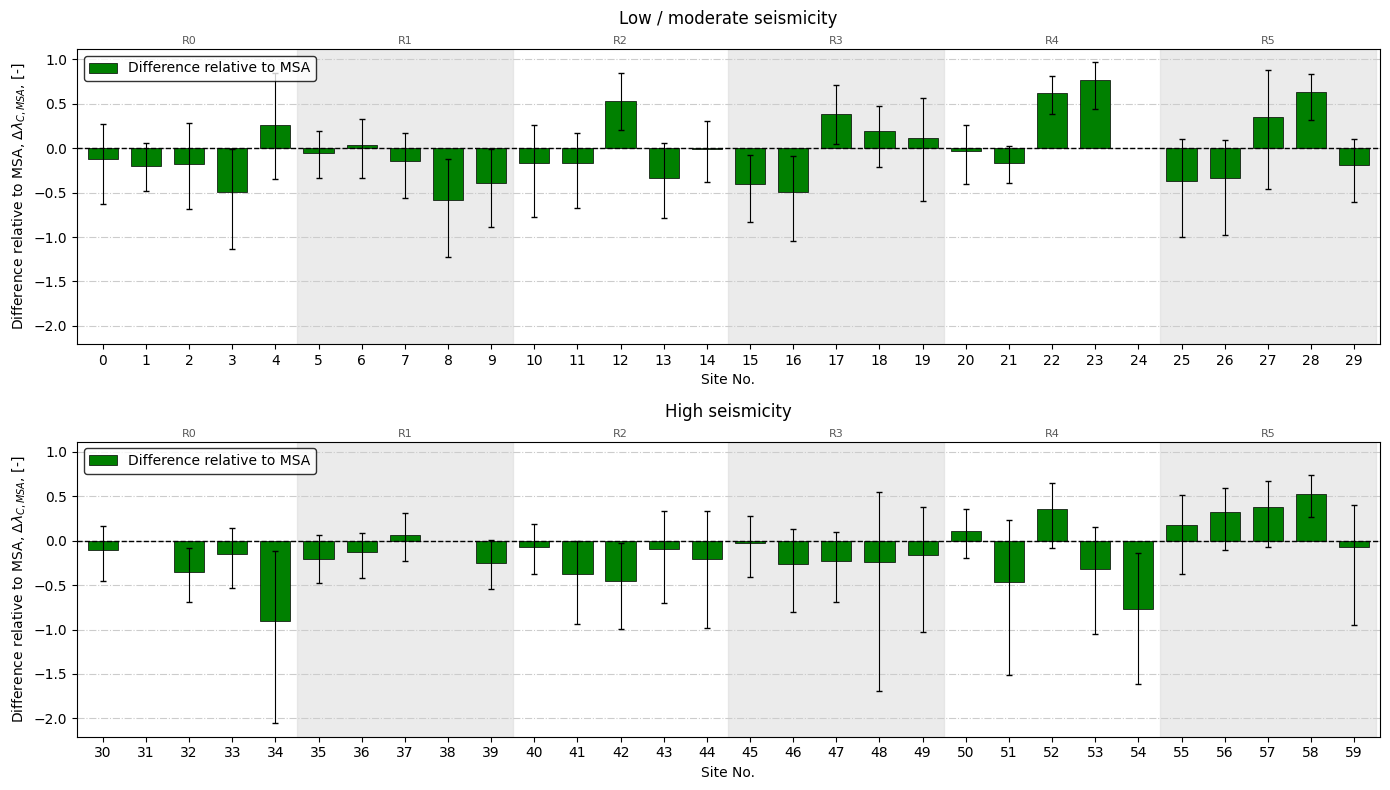

In [55]:
fig, axs = mih.plot_site_statistic(
    bootstrap_stats, "mafc_rel_msa",
    r"Difference relative to MSA, $\Delta\lambda_{C,MSA}$, [-]", hline=0.0,
    save_fp=OUT_FOLDER / "site_comparison_mafc_rel_msa.jpg")

#### Pooling stats across sites

In [56]:
summary_stats.columns

Index(['statistically_different', 'rho_msa', 'rho_ida', 'msa_pt_estimate',
       'ida_pt_estimate', 'd_orig', 'd_corr', 'd_bar', 'covar',
       'test_distance', 'CI_distance', 'achieved_sig_level'],
      dtype='object')

Stat         Theta_ratio  Beta_ratio
------------------------------------
N_obs             57.000      57.000
min                0.827       0.685
max                1.172       1.790
mean               1.035       1.082
median             1.057       1.057
variance           0.007       0.043
std                0.086       0.209
2.5pc              0.831       0.731
5pc                0.845       0.807
16pc               0.959       0.922
84pc               1.108       1.252
95pc               1.150       1.452
97.5pc             1.168       1.619
skewness      -8.636e-01   1.046e+00
kurtosis           0.273       2.015



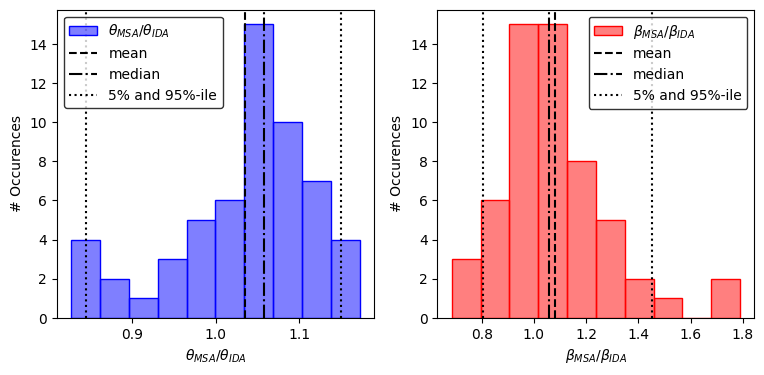

In [57]:
# theta_ratio - obtained from d_corr - the bias corrected data that I actually collected
# `pooled` keeps the structure tag (and so the site) against every ratio, so
# the pooled values can be joined to per-site quantities further down.
pooled = mih.build_pooled_ratio_frame(summary_stats)
theta_ratio = pooled["theta_ratio"].to_numpy()
beta_ratio = pooled["beta_ratio"].to_numpy()

theta_ratio_stats = mih.get_stats(theta_ratio)
beta_ratio_stats = mih.get_stats(beta_ratio)

mih.print_stats((theta_ratio_stats, beta_ratio_stats), ("Theta_ratio", "Beta_ratio"))

fig, axs = plt.subplots(1, 2, figsize=(9, 4))
axs[0].hist(theta_ratio, label=r"$\theta_{MSA}/\theta_{IDA}$",
            facecolor=[(0.0, 0.0, 1.0, 0.5)], edgecolor=[(0.0, 0.0, 1.0, 1.0)],
            )
axs[0].axvline(theta_ratio_stats["mean"], ls="--", color="k", label="mean")
axs[0].axvline(theta_ratio_stats["median"], ls="-.", color="k", label="median")
axs[0].axvline(theta_ratio_stats["5pc"], ls=":", color="k", label=r"5% and 95%-ile")
axs[0].axvline(theta_ratio_stats["95pc"], ls=":", color="k")

axs[1].hist(beta_ratio, label=r"$\beta_{MSA}/\beta_{IDA}$",
            facecolor=[(1.0, 0.0, 0.0, 0.5)], edgecolor=[(1.0, 0.0, 0.0, 1.0)],
            )
axs[1].axvline(beta_ratio_stats["mean"], ls="--", color="k", label="mean")
axs[1].axvline(beta_ratio_stats["median"], ls="-.", color="k", label="median")
axs[1].axvline(beta_ratio_stats["5pc"], ls=":", color="k", label=r"5% and 95%-ile")
axs[1].axvline(beta_ratio_stats["95pc"], ls=":", color="k")

axs[0].set_ylabel("# Occurences")
axs[0].set_xlabel(r"$\theta_{MSA}/\theta_{IDA}$")
axs[1].set_ylabel("# Occurences")
axs[1].set_xlabel(r"$\beta_{MSA}/\beta_{IDA}$")

mih.style_legend(axs[0])
mih.style_legend(axs[1])

##### Fitted dispersion against fitted median

The histograms above pool the two parameters separately. This pair of panels keeps
them together, one point per structure, to show whether a structure that is fitted
with a higher median collapse capacity is also fitted with a wider dispersion - and
whether the two arms answer that question the same way.

Both panels are split by seismicity band with a trend line and statistics for each
band and for the pooled set. Points coincide where several sites share a design and
therefore share an exact `(theta, beta)` pair.

,,slope,intercept,r2,spearman_rho,n_sites
arm,group,,,,,
msa,all,0.082234,0.185608,0.065277,0.099430,57
ida,all,0.171818,0.123994,0.640349,0.646883,57
msa,lowmod,-0.340240,0.367117,0.114915,-0.216749,29
ida,lowmod,0.013694,0.188978,0.001057,0.566523,29
msa,high,0.209162,0.098746,0.455818,0.615764,28
ida,high,0.217388,0.094854,0.729665,0.767724,28


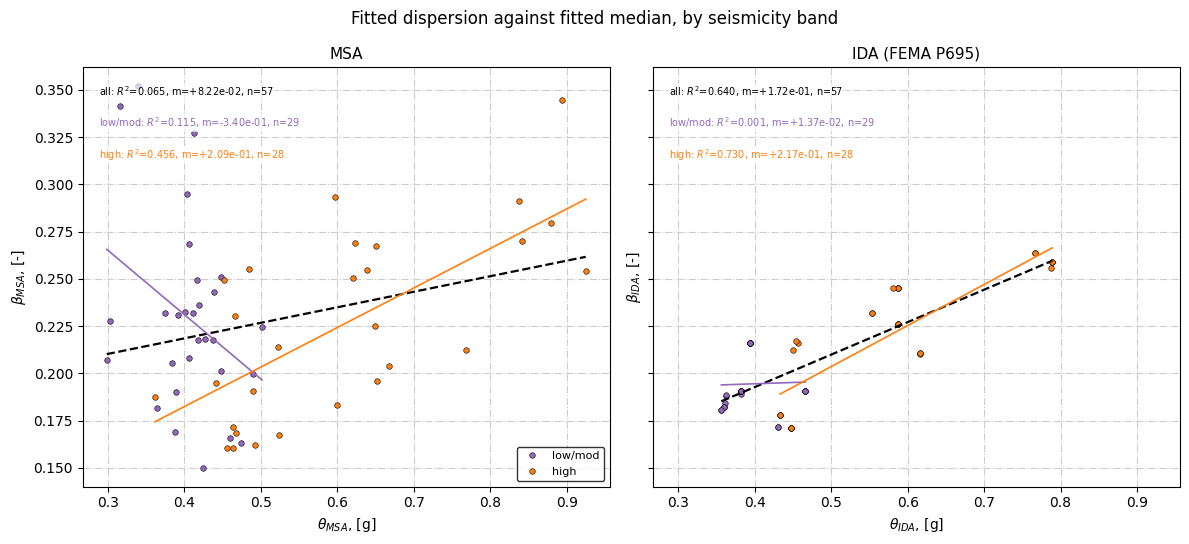

In [58]:
fig_tb, axs_tb, theta_beta_fits = mih.plot_theta_beta_by_band(
    pooled, disagg_stats)

theta_beta_fits

Stat            mafc-msa    mafc-ida       ratio
------------------------------------------------
N_obs             57.000      57.000      57.000
min            3.381e-07   5.136e-07   5.350e-01
max            1.173e-04   1.306e-04   4.070e+00
mean           2.097e-05   2.127e-05   1.072e+00
median         1.166e-05   1.192e-05   8.694e-01
variance       5.354e-10   5.966e-10   3.560e-01
std            2.334e-05   2.464e-05   6.019e-01
2.5pc          8.162e-07   6.469e-07   5.938e-01
5pc            1.017e-06   1.213e-06   6.527e-01
16pc           3.149e-06   3.678e-06   7.298e-01
84pc           3.980e-05   3.969e-05   1.406e+00
95pc           6.505e-05   6.548e-05   2.222e+00
97.5pc         7.532e-05   7.896e-05   2.616e+00
skewness           1.895       2.152       2.950
kurtosis           4.045       5.605      10.142



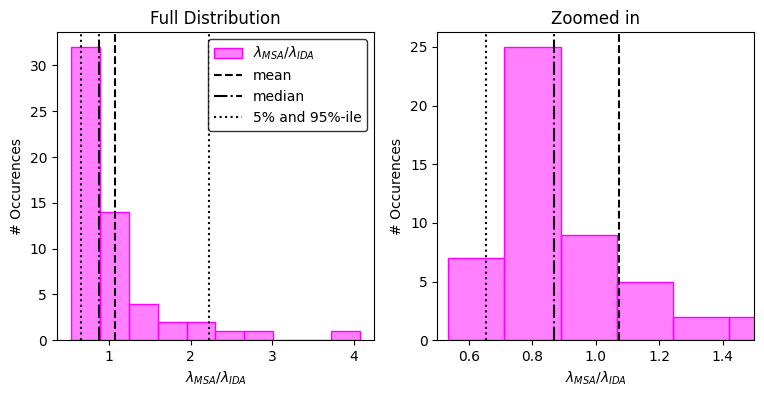

In [59]:
## Mean annual frequency of collapse
# calculate the mean annual frequency of collapse across the corrected point estimates
pooled = mih.add_mafc_ratios(pooled, summary_stats, hcs)
mafcs_msa = pooled["mafc_msa"].to_numpy()
mafcs_ida = pooled["mafc_ida"].to_numpy()
mafcs_rat = pooled["mafc_ratio"].to_numpy()

mafcs_msa_stats = mih.get_stats(mafcs_msa)
mafcs_ida_stats = mih.get_stats(mafcs_ida)
mafcs_rat_stats = mih.get_stats(mafcs_rat)

mih.print_stats((mafcs_msa_stats, mafcs_ida_stats, mafcs_rat_stats), ("mafc-msa", "mafc-ida", "ratio"))

fig, axs = plt.subplots(1, 2, figsize=(9, 4))
axs[0].hist(mafcs_rat, label=r"$\lambda_{MSA}/\lambda_{IDA}$",
            facecolor=[(1.0, 0.0, 1.0, 0.5)], edgecolor=[(1.0, 0.0, 1.0, 1.0)],
            )
axs[0].axvline(mafcs_rat_stats["mean"], ls="--", color="k", label="mean")
axs[0].axvline(mafcs_rat_stats["median"], ls="-.", color="k", label="median")
axs[0].axvline(mafcs_rat_stats["5pc"], ls=":", color="k", label=r"5% and 95%-ile")
axs[0].axvline(mafcs_rat_stats["95pc"], ls=":", color="k")

axs[0].set_ylabel("# Occurences")
axs[0].set_xlabel(r"$\lambda_{MSA}/\lambda_{IDA}$")
axs[0].set_title("Full Distribution")

axs[1].hist(mafcs_rat, label=r"$\lambda_{MSA}/\lambda_{IDA}$",
            facecolor=[(1.0, 0.0, 1.0, 0.5)], edgecolor=[(1.0, 0.0, 1.0, 1.0)],
            bins=20)
axs[1].axvline(mafcs_rat_stats["mean"], ls="--", color="k", label="mean")
axs[1].axvline(mafcs_rat_stats["median"], ls="-.", color="k", label="median")
axs[1].axvline(mafcs_rat_stats["5pc"], ls=":", color="k", label=r"5% and 95%-ile")
axs[1].axvline(mafcs_rat_stats["95pc"], ls=":", color="k")

axs[1].set_ylabel("# Occurences")
axs[1].set_xlabel(r"$\lambda_{MSA}/\lambda_{IDA}$")
axs[1].set_xlim(0.5, 1.5)
axs[1].set_title("Zoomed in")

mih.style_legend(axs[0])

#### Design-normalised collapse capacity

`theta` itself is dominated by how strong the site's hazard is, which makes the two
seismicity bands incomparable. Dividing by the 475-year AvgSA(0-3s) - the EC8
no-collapse design intensity, interpolated from the site's own hazard curve - gives
the margin between where the structure actually collapses and what it was designed
for, on a scale both bands share.

In [60]:
pooled = mih.add_design_normalised_medians(pooled, hcs, return_period=475)

pooled[["sa_design", "theta_msa", "theta_msa_norm", "theta_ida_norm"]].describe()

,sa_design,theta_msa,theta_msa_norm,theta_ida_norm
count,57.000000,57.000000,57.000000,57.000000
mean,0.070700,0.503766,9.104918,8.677473
std,0.040081,0.152494,4.830632,4.325047
min,0.018318,0.298323,3.341194,3.444877
25%,0.039457,0.406390,6.029920,5.602802
50%,0.059800,0.455806,7.597399,7.267649
75%,0.106034,0.596995,10.156411,9.652851
max,0.178677,0.924889,22.775136,21.462413


#### Ad-hoc proxies for predicting variation in the results

In [61]:
disagg_stats.columns

Index(['lat', 'lon', 'seismicity', 'region', 'imt', 'poe', 'mafe', 'rtp',
       'Craton [%]', 'Non-Subduction Deep [%]', 'Shallow Default [%]',
       'Subduction Inslab [%]', 'Subduction Interface [%]', 'Volcanic [%]',
       'Mag_mean', 'Dist_mean'],
      dtype='object')

##### Ratio vs. shallow-crustal contribution, by IM level

Each panel regresses one pooled MSA/IDA ratio on the percentage of the hazard
contributed by the *Shallow Default* tectonic region, at one IM level of the
disaggregation. The grid is 5x3 because the disaggregation carries 13 IM levels;
the two spare axes are switched off.

Two caveats travel with these fits:

- The proxy is heavily clustered at 100% (median ~99.9%, lower quartile ~63%), so
  the least-squares $R^2$ is carried by the minority of sites with a real
  subduction or deep contribution. The rank-based $\rho_{Spearman}$ is reported
  alongside it in the returned frame for that reason.
- The site count thins at the top of the IM range - the highest levels are only
  reached by the hazard curves of the more active sites - so the last panels are
  fitted on fewer points and their `n_sites` should be read before their $R^2$.


Every panel is split by seismicity band: the low/moderate sites in purple, the
high-seismicity sites in orange, each with its own trend line and statistics, and
the pooled fit over the top as a black dashed line. The split is not cosmetic. The
two bands differ in *both* the proxy (mean %ASC 86 vs 71) and in most of the
responses, so a pooled slope can take a sign that neither band shows on its own -
`beta_ida` is exactly that case. Read the band rows before the `all` row.


,,slope,intercept,r2,spearman_rho,n_sites
imtl,group,,,,,
0.270,all,0.000419,1.049164,0.004911,0.043791,57
0.285,all,0.000444,1.047093,0.005520,0.046365,57
0.310,all,0.000487,1.043634,0.006613,0.046873,57
0.330,all,0.000519,1.041005,0.007504,0.050396,57
0.360,all,0.000566,1.037126,0.008912,0.068843,57
0.400,all,0.000626,1.032195,0.010843,0.078845,57
0.450,all,0.000697,1.026314,0.013330,0.084570,57
0.500,all,0.000768,1.020317,0.016049,0.086250,57
0.550,all,0.000838,1.014412,0.018942,0.087158,57


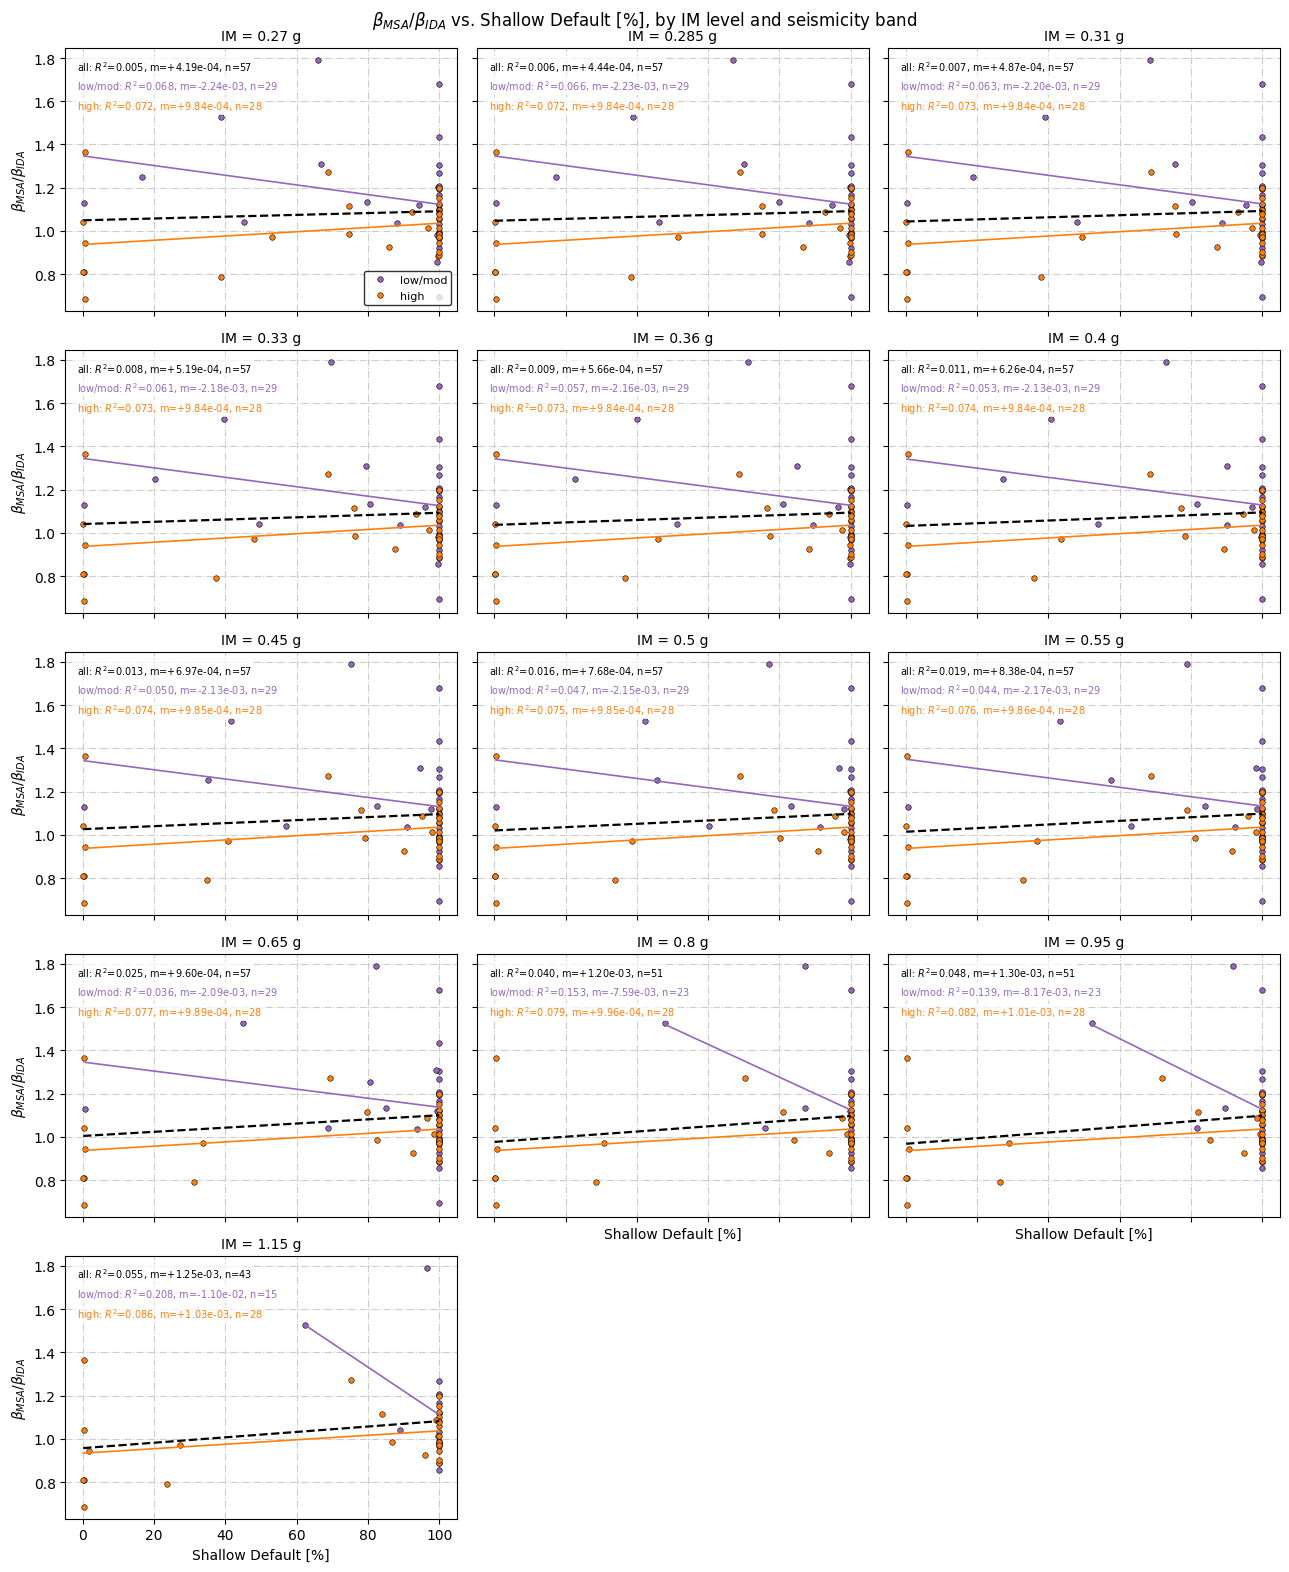

In [62]:
PROXY = "Shallow Default [%]"

fig_beta, axs_beta, beta_fits = mih.plot_ratio_vs_proxy(
    pooled, disagg_stats, "beta_ratio", PROXY,
    ylabel=r"$\beta_{MSA}/\beta_{IDA}$")

beta_fits

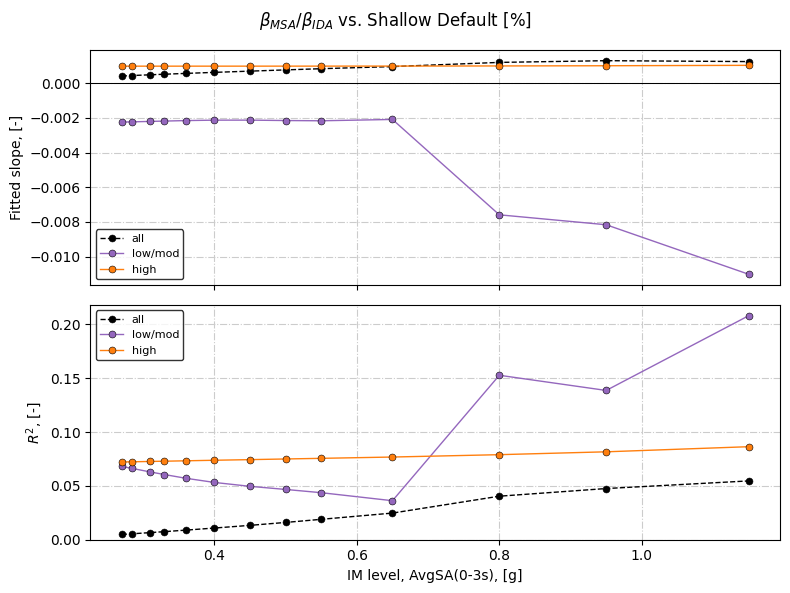

In [63]:
fig_beta_trend, axs_beta_trend = mih.plot_fit_trend_vs_iml(
    beta_fits, title=r"$\beta_{MSA}/\beta_{IDA}$ vs. " + PROXY)

The same regression for the median ratio and for the collapse risk ratio.

,,slope,intercept,r2,spearman_rho,n_sites
imtl,group,,,,,
0.270,all,0.001607,0.908934,0.430300,0.417281,57
0.285,all,0.001603,0.909052,0.427293,0.414978,57
0.310,all,0.001595,0.909340,0.421962,0.414613,57
0.330,all,0.001587,0.909646,0.417460,0.408110,57
0.360,all,0.001576,0.910192,0.410285,0.425527,57
0.400,all,0.001559,0.911035,0.399943,0.427891,57
0.450,all,0.001537,0.912250,0.385741,0.420898,57
0.500,all,0.001511,0.913792,0.369185,0.415721,57
0.550,all,0.001479,0.915862,0.350735,0.428023,57


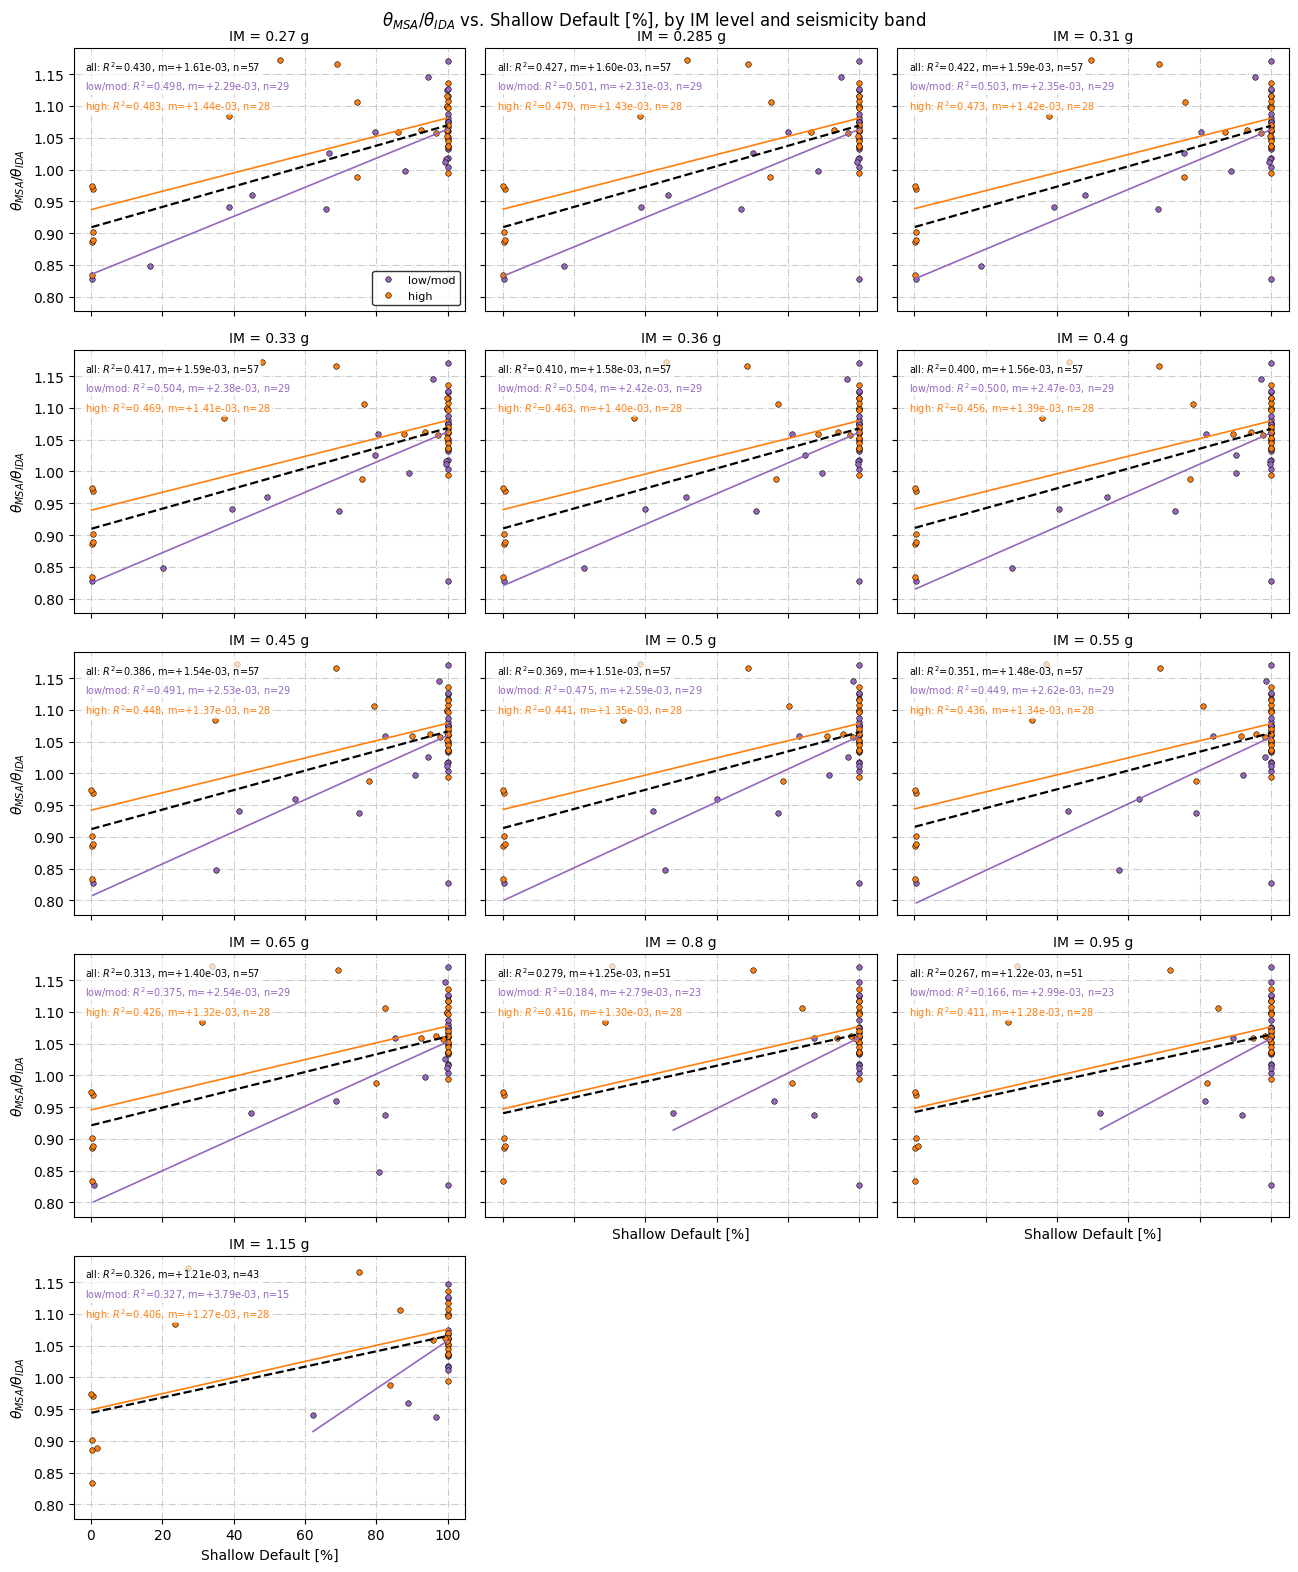

In [64]:
fig_theta, axs_theta, theta_fits = mih.plot_ratio_vs_proxy(
    pooled, disagg_stats, "theta_ratio", PROXY,
    ylabel=r"$\theta_{MSA}/\theta_{IDA}$")

theta_fits

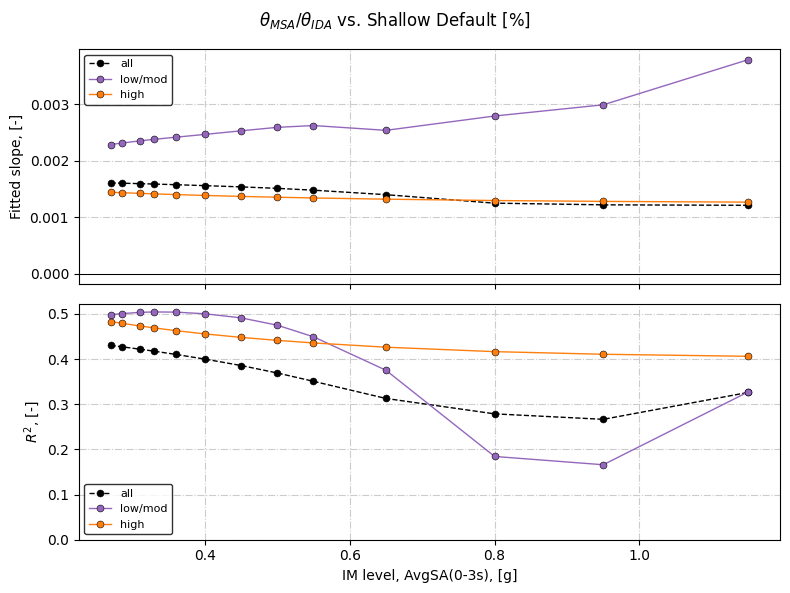

In [65]:
fig_theta_trend, axs_theta_trend = mih.plot_fit_trend_vs_iml(
    theta_fits, title=r"$\theta_{MSA}/\theta_{IDA}$ vs. " + PROXY)

,,slope,intercept,r2,spearman_rho,n_sites
imtl,group,,,,,
0.270,all,-0.007689,1.676302,0.199510,-0.398620,57
0.285,all,-0.007648,1.674073,0.197026,-0.395640,57
0.310,all,-0.007573,1.669754,0.192666,-0.395511,57
0.330,all,-0.007509,1.665935,0.189100,-0.389144,57
0.360,all,-0.007406,1.659524,0.183455,-0.398957,57
0.400,all,-0.007257,1.649918,0.175389,-0.390868,57
0.450,all,-0.007053,1.636121,0.164382,-0.383292,57
0.500,all,-0.006805,1.618769,0.151579,-0.378047,57
0.550,all,-0.006516,1.597874,0.137871,-0.387327,57


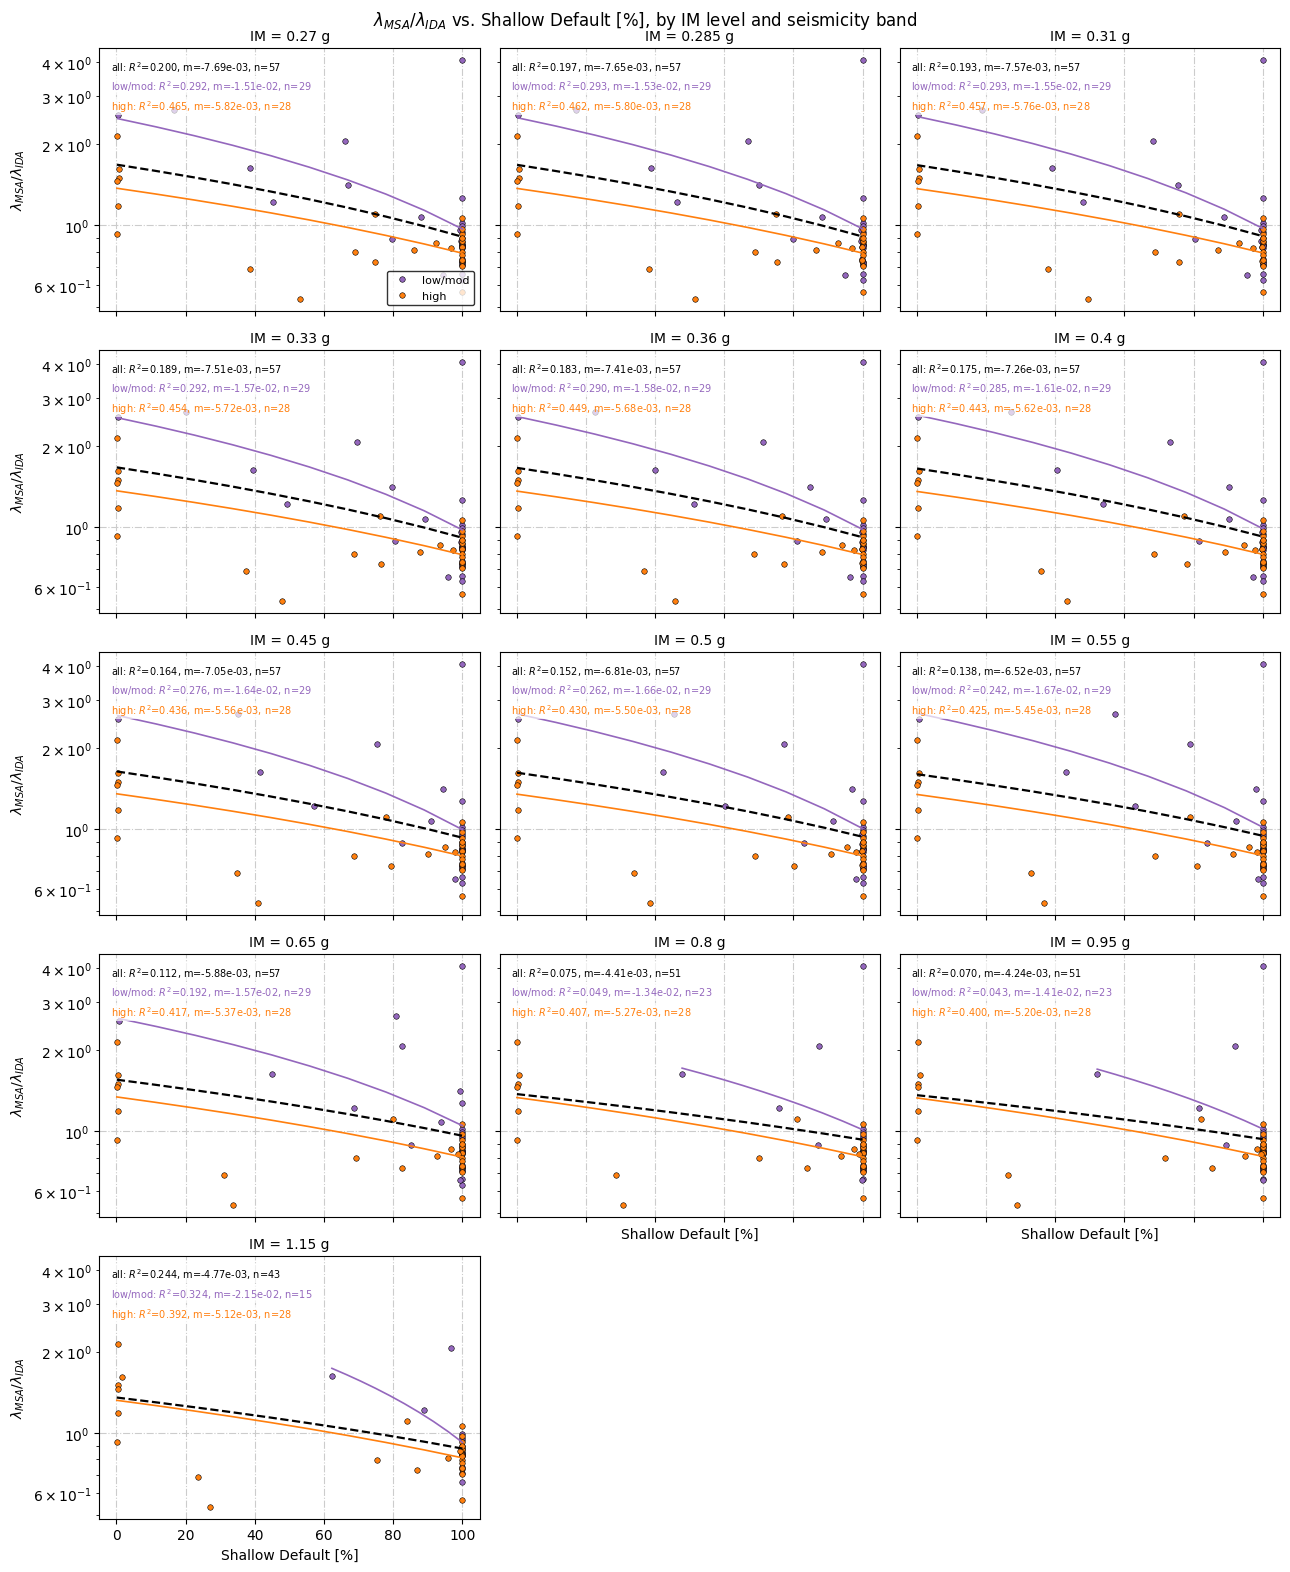

In [66]:
# log y-axis: the risk ratio runs from 0.54 to 4.07 across the sites
fig_mafc, axs_mafc, mafc_fits = mih.plot_ratio_vs_proxy(
    pooled, disagg_stats, "mafc_ratio", PROXY,
    ylabel=r"$\lambda_{MSA}/\lambda_{IDA}$", log_y=True)

mafc_fits

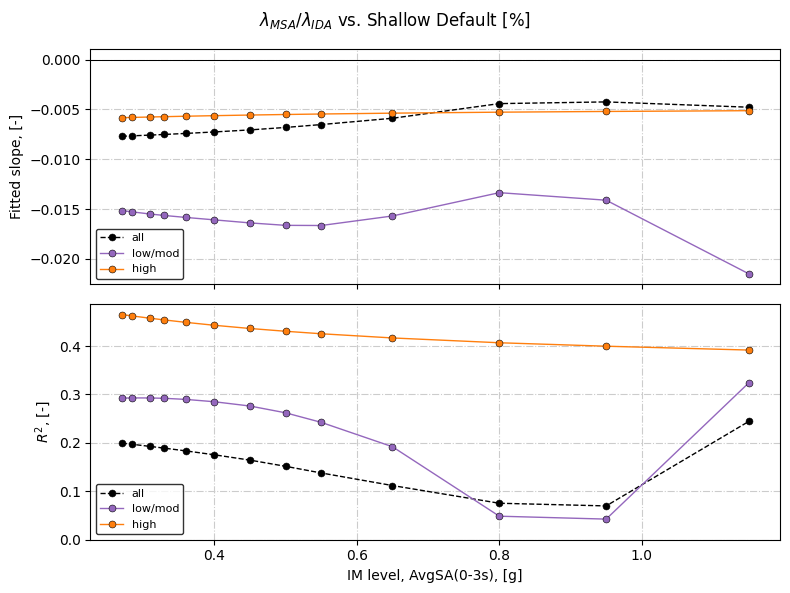

In [67]:
fig_mafc_trend, axs_mafc_trend = mih.plot_fit_trend_vs_iml(
    mafc_fits, title=r"$\lambda_{MSA}/\lambda_{IDA}$ vs. " + PROXY)

The same regression again, but on the dispersions themselves rather than on
their ratio. If the proxy drives the *level* of a dispersion in both arms equally
it will not show up in `beta_fits` at all, so the two arms are worth looking at
separately before concluding anything from the ratio.

,,slope,intercept,r2,spearman_rho,n_sites
imtl,group,,,,,
0.270,all,0.000035,0.224262,0.000631,-0.029634,57
0.285,all,0.000039,0.223934,0.000785,-0.026518,57
0.310,all,0.000046,0.223384,0.001080,-0.029127,57
0.330,all,0.000051,0.222978,0.001326,-0.028449,57
0.360,all,0.000058,0.222398,0.001717,-0.020881,57
0.400,all,0.000066,0.221744,0.002209,0.004045,57
0.450,all,0.000074,0.221110,0.002724,0.005039,57
0.500,all,0.000080,0.220606,0.003148,-0.000617,57
0.550,all,0.000085,0.220181,0.003519,0.020504,57


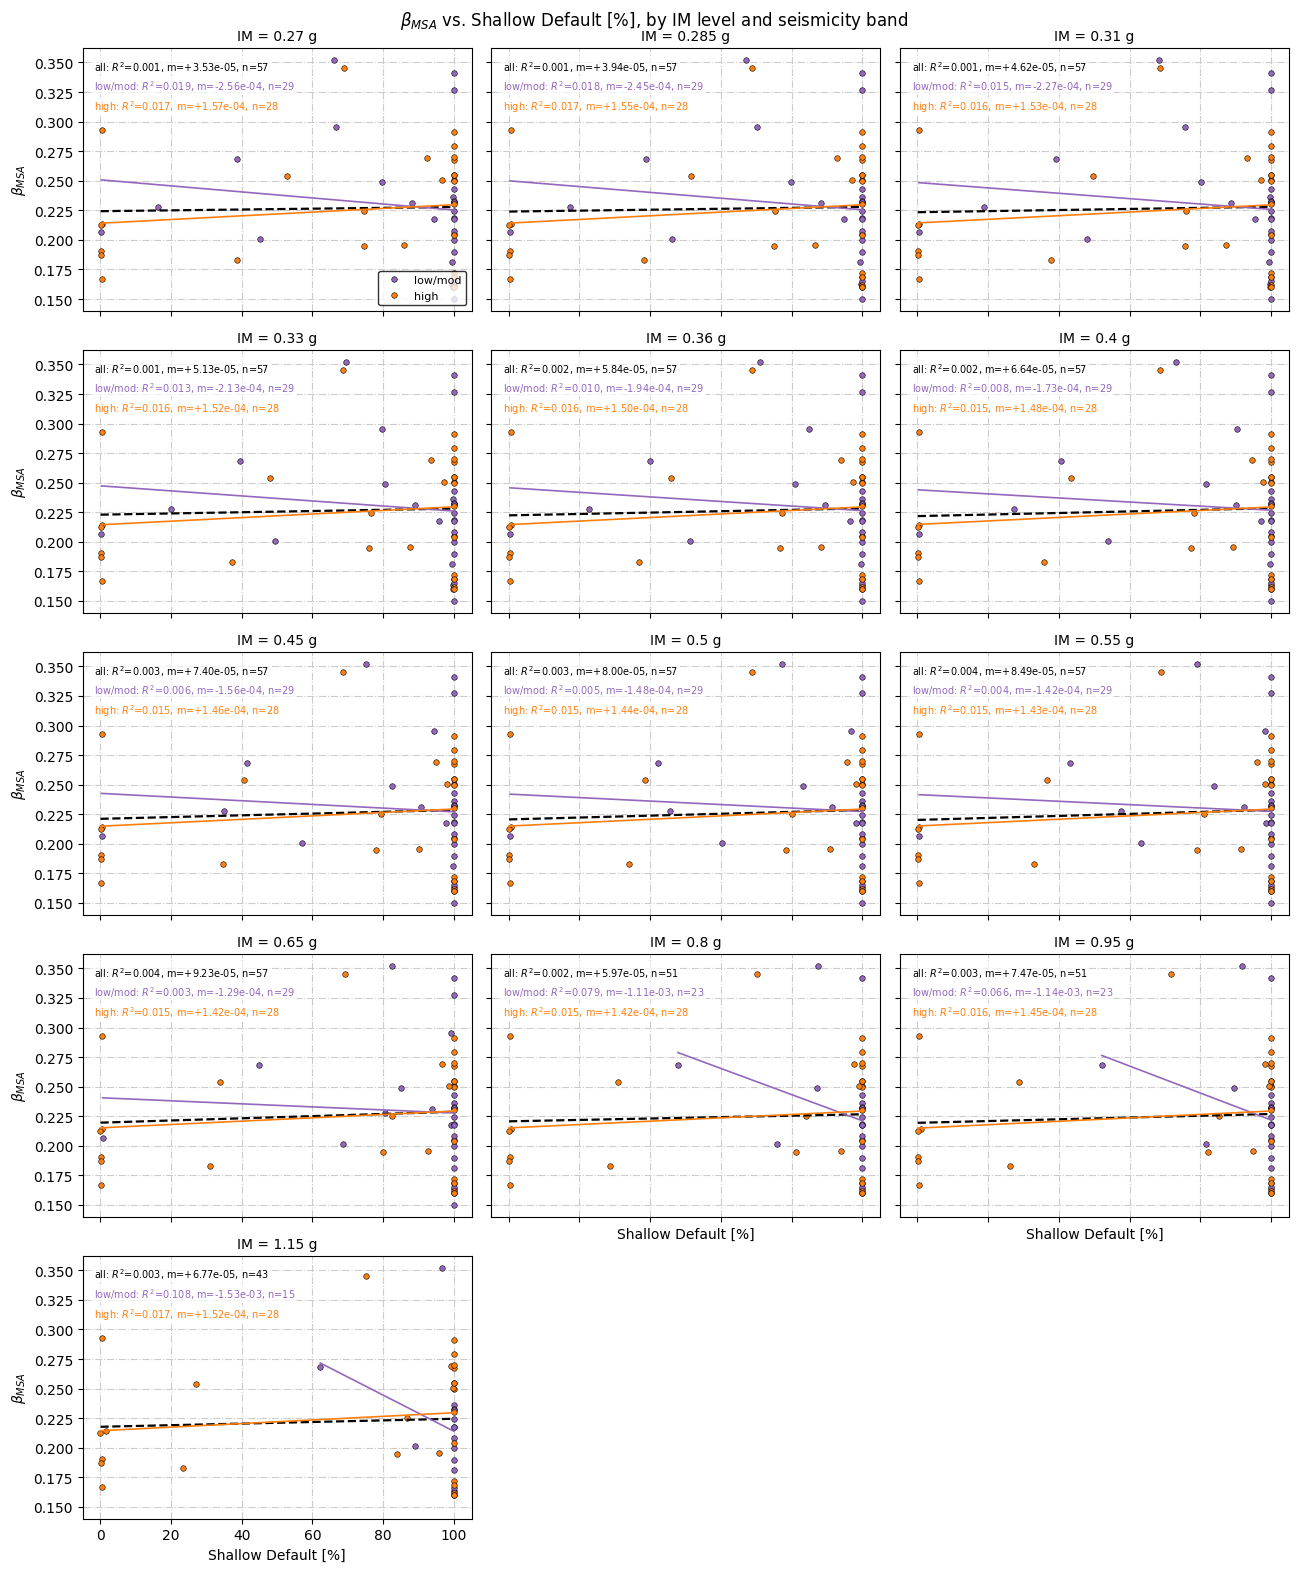

In [68]:
fig_bmsa, axs_bmsa, beta_msa_fits = mih.plot_ratio_vs_proxy(
    pooled, disagg_stats, "beta_msa", PROXY, ylabel=r"$\beta_{MSA}$")

beta_msa_fits

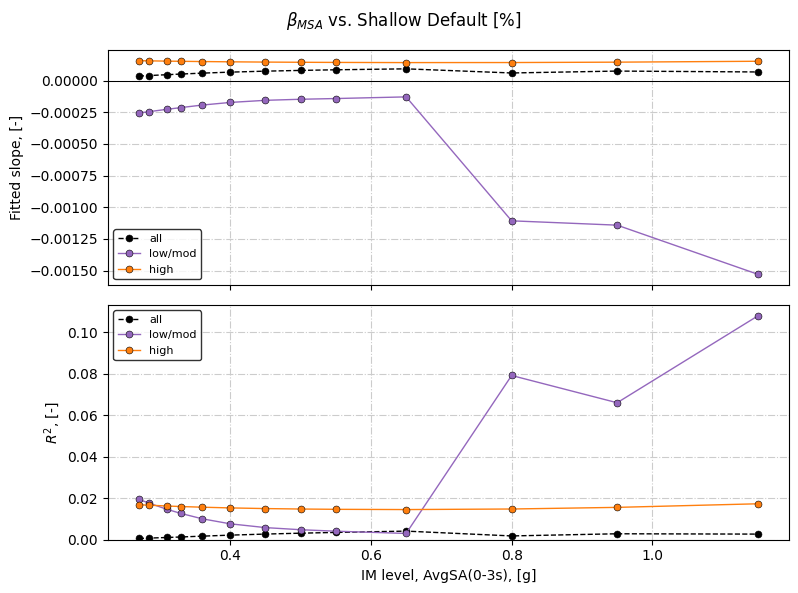

In [69]:
fig_bmsa_trend, axs_bmsa_trend = mih.plot_fit_trend_vs_iml(
    beta_msa_fits, title=r"$\beta_{MSA}$ vs. " + PROXY)

,,slope,intercept,r2,spearman_rho,n_sites
imtl,group,,,,,
0.270,all,-0.000122,0.216811,0.023069,-0.146989,57
0.285,all,-0.000123,0.216969,0.023717,-0.148245,57
0.310,all,-0.000126,0.217226,0.024790,-0.152934,57
0.330,all,-0.000129,0.217427,0.025644,-0.157637,57
0.360,all,-0.000132,0.217732,0.026973,-0.173677,57
0.400,all,-0.000137,0.218178,0.028971,-0.150260,57
0.450,all,-0.000145,0.218818,0.031930,-0.157082,57
0.500,all,-0.000153,0.219570,0.035547,-0.162908,57
0.550,all,-0.000162,0.220342,0.039471,-0.138115,57


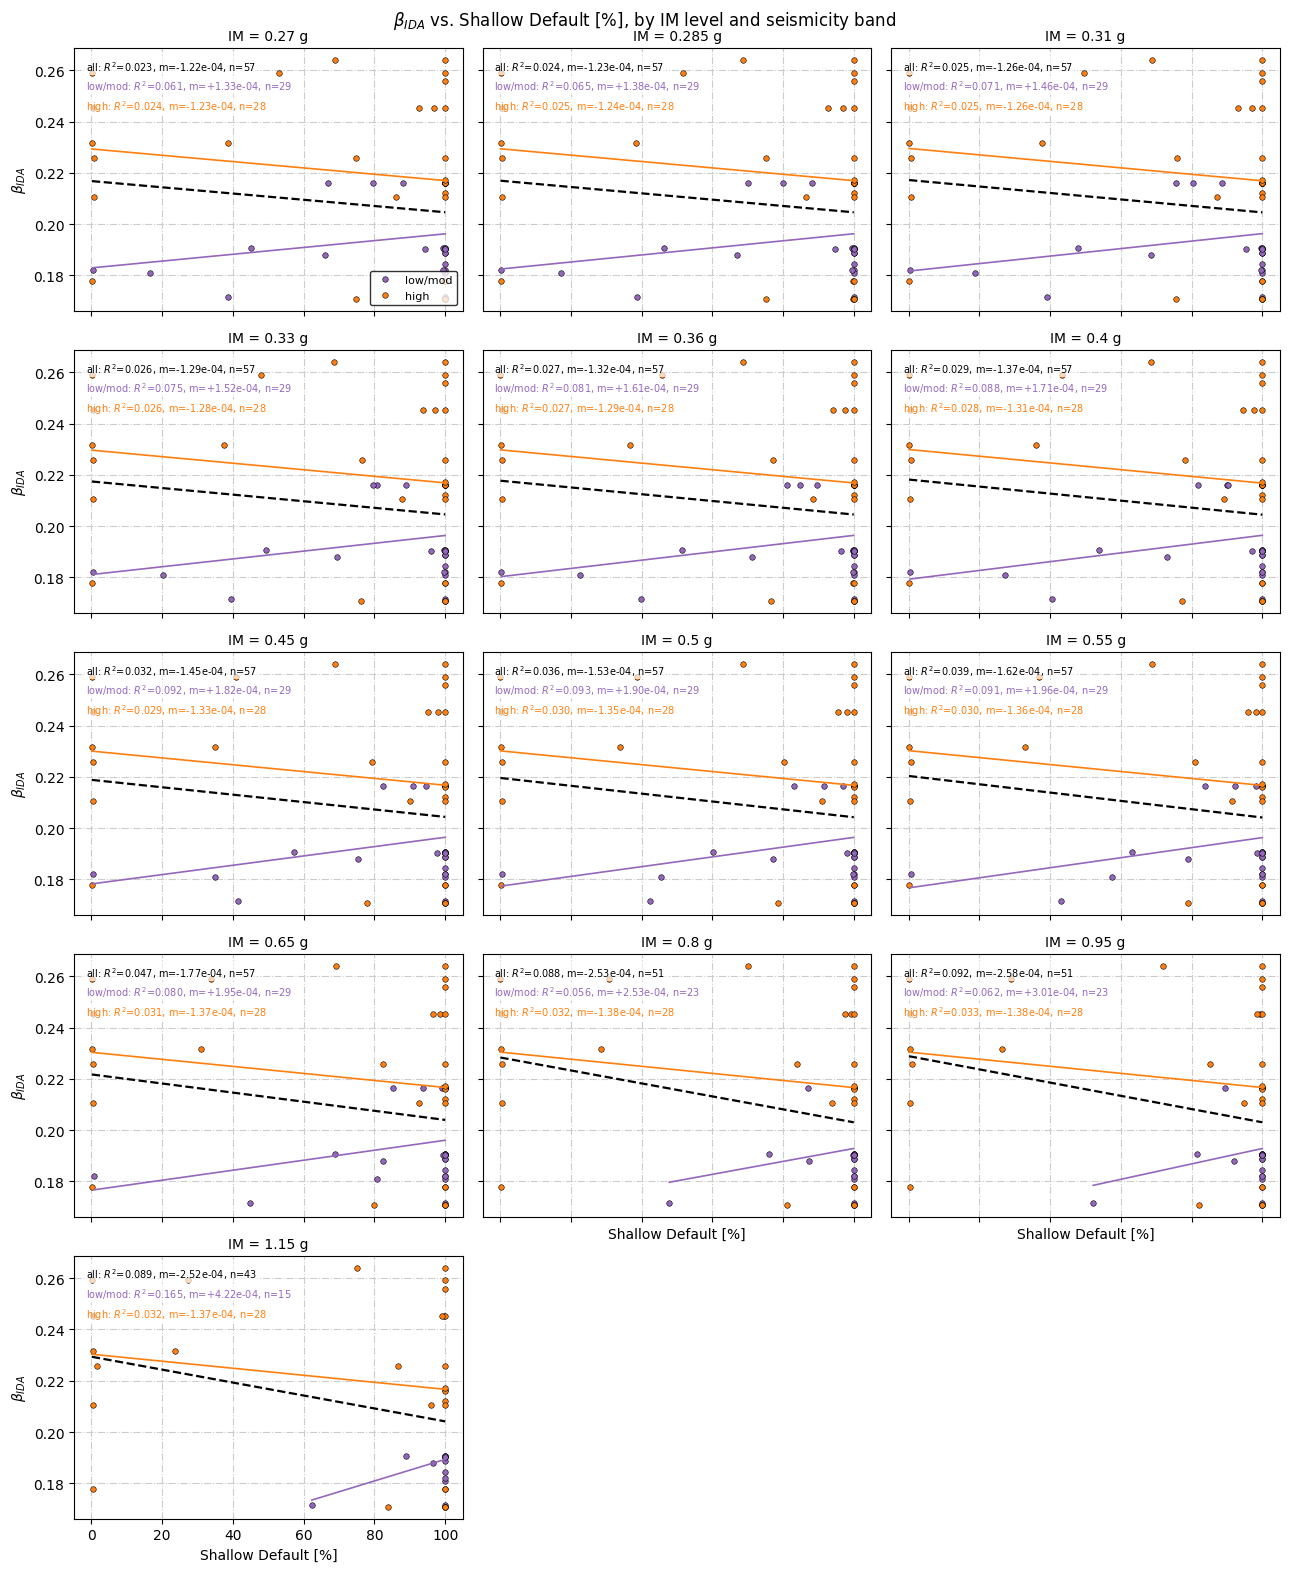

In [70]:
fig_bida, axs_bida, beta_ida_fits = mih.plot_ratio_vs_proxy(
    pooled, disagg_stats, "beta_ida", PROXY, ylabel=r"$\beta_{IDA}$")

beta_ida_fits

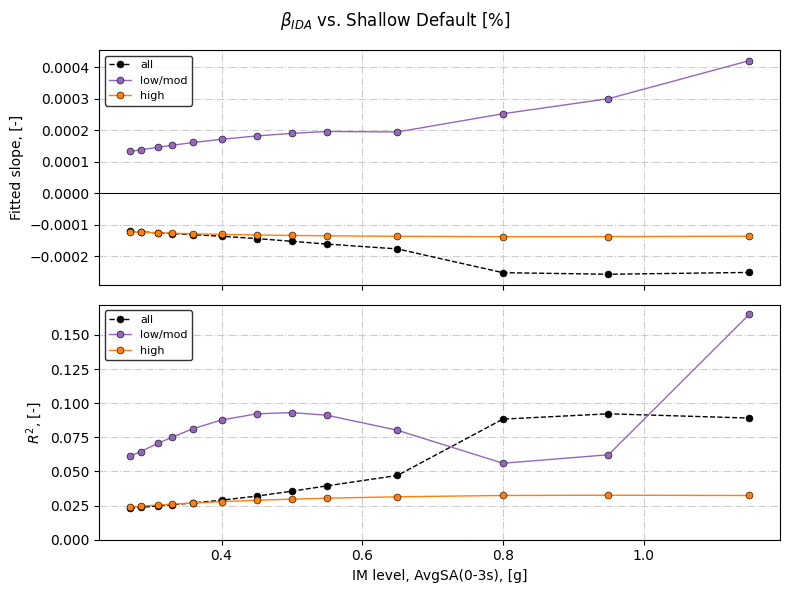

In [71]:
fig_bida_trend, axs_bida_trend = mih.plot_fit_trend_vs_iml(
    beta_ida_fits, title=r"$\beta_{IDA}$ vs. " + PROXY)

And on the design-normalised medians - how far above the intensity it was designed
for each structure actually collapses.

,,slope,intercept,r2,spearman_rho,n_sites
imtl,group,,,,,
0.270,all,0.068341,3.731842,0.244706,0.592850,57
0.285,all,0.068454,3.714067,0.245065,0.594137,57
0.310,all,0.068597,3.688209,0.245454,0.595028,57
0.330,all,0.068671,3.671175,0.245555,0.599668,57
0.360,all,0.068745,3.648945,0.245445,0.607837,57
0.400,all,0.068811,3.623160,0.244814,0.612561,57
0.450,all,0.068865,3.594389,0.243340,0.612766,57
0.500,all,0.068848,3.570838,0.240896,0.615989,57
0.550,all,0.068604,3.565563,0.237312,0.608552,57


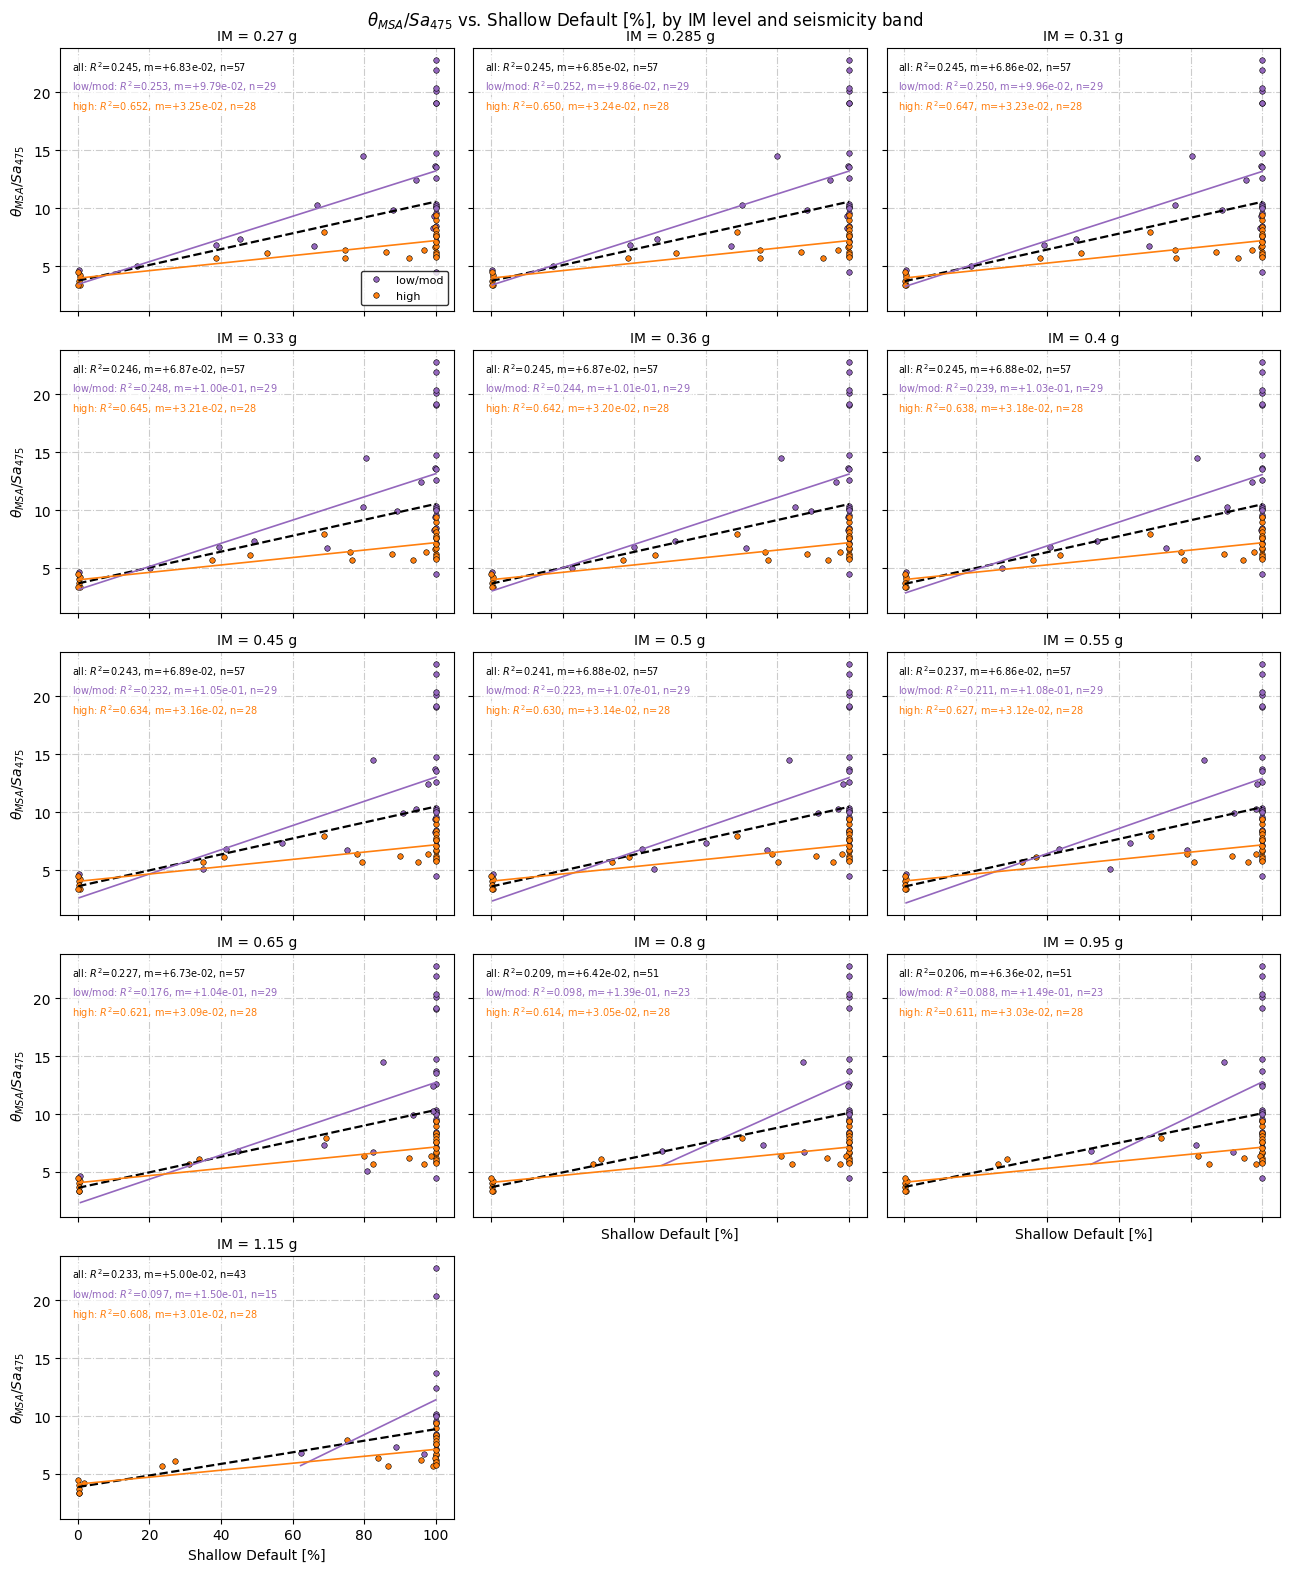

In [72]:
fig_tmn, axs_tmn, theta_msa_norm_fits = mih.plot_ratio_vs_proxy(
    pooled, disagg_stats, "theta_msa_norm", PROXY,
    ylabel=r"$\theta_{MSA}/Sa_{475}$")

theta_msa_norm_fits

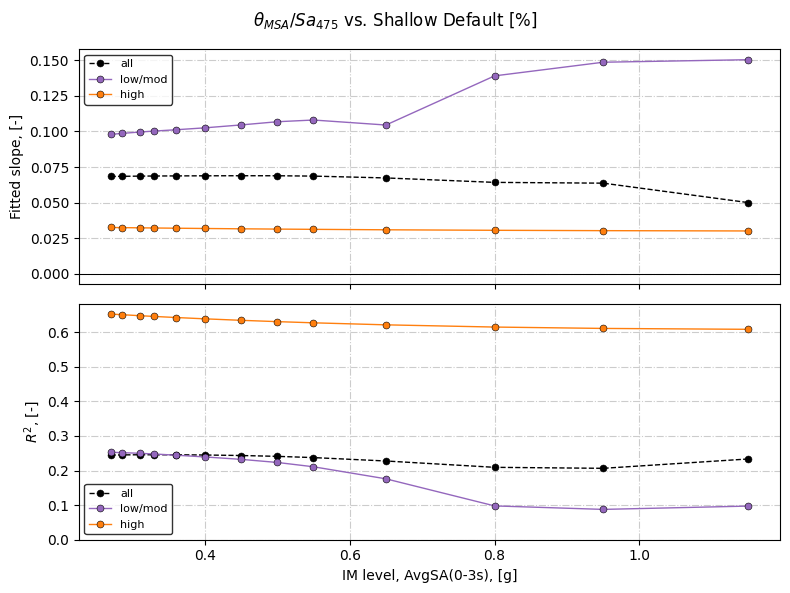

In [73]:
fig_tmn_trend, axs_tmn_trend = mih.plot_fit_trend_vs_iml(
    theta_msa_norm_fits, title=r"$\theta_{MSA}/Sa_{475}$ vs. " + PROXY)

,,slope,intercept,r2,spearman_rho,n_sites
imtl,group,,,,,
0.270,all,0.056291,4.251758,0.207105,0.555528,57
0.285,all,0.056437,4.232998,0.207794,0.557289,57
0.310,all,0.056642,4.204757,0.208770,0.558112,57
0.330,all,0.056772,4.185273,0.209361,0.564140,57
0.360,all,0.056936,4.158748,0.210023,0.567982,57
0.400,all,0.057126,4.126584,0.210482,0.573172,57
0.450,all,0.057343,4.088934,0.210476,0.575126,57
0.500,all,0.057515,4.054395,0.209714,0.580508,57
0.550,all,0.057505,4.034315,0.207996,0.570686,57


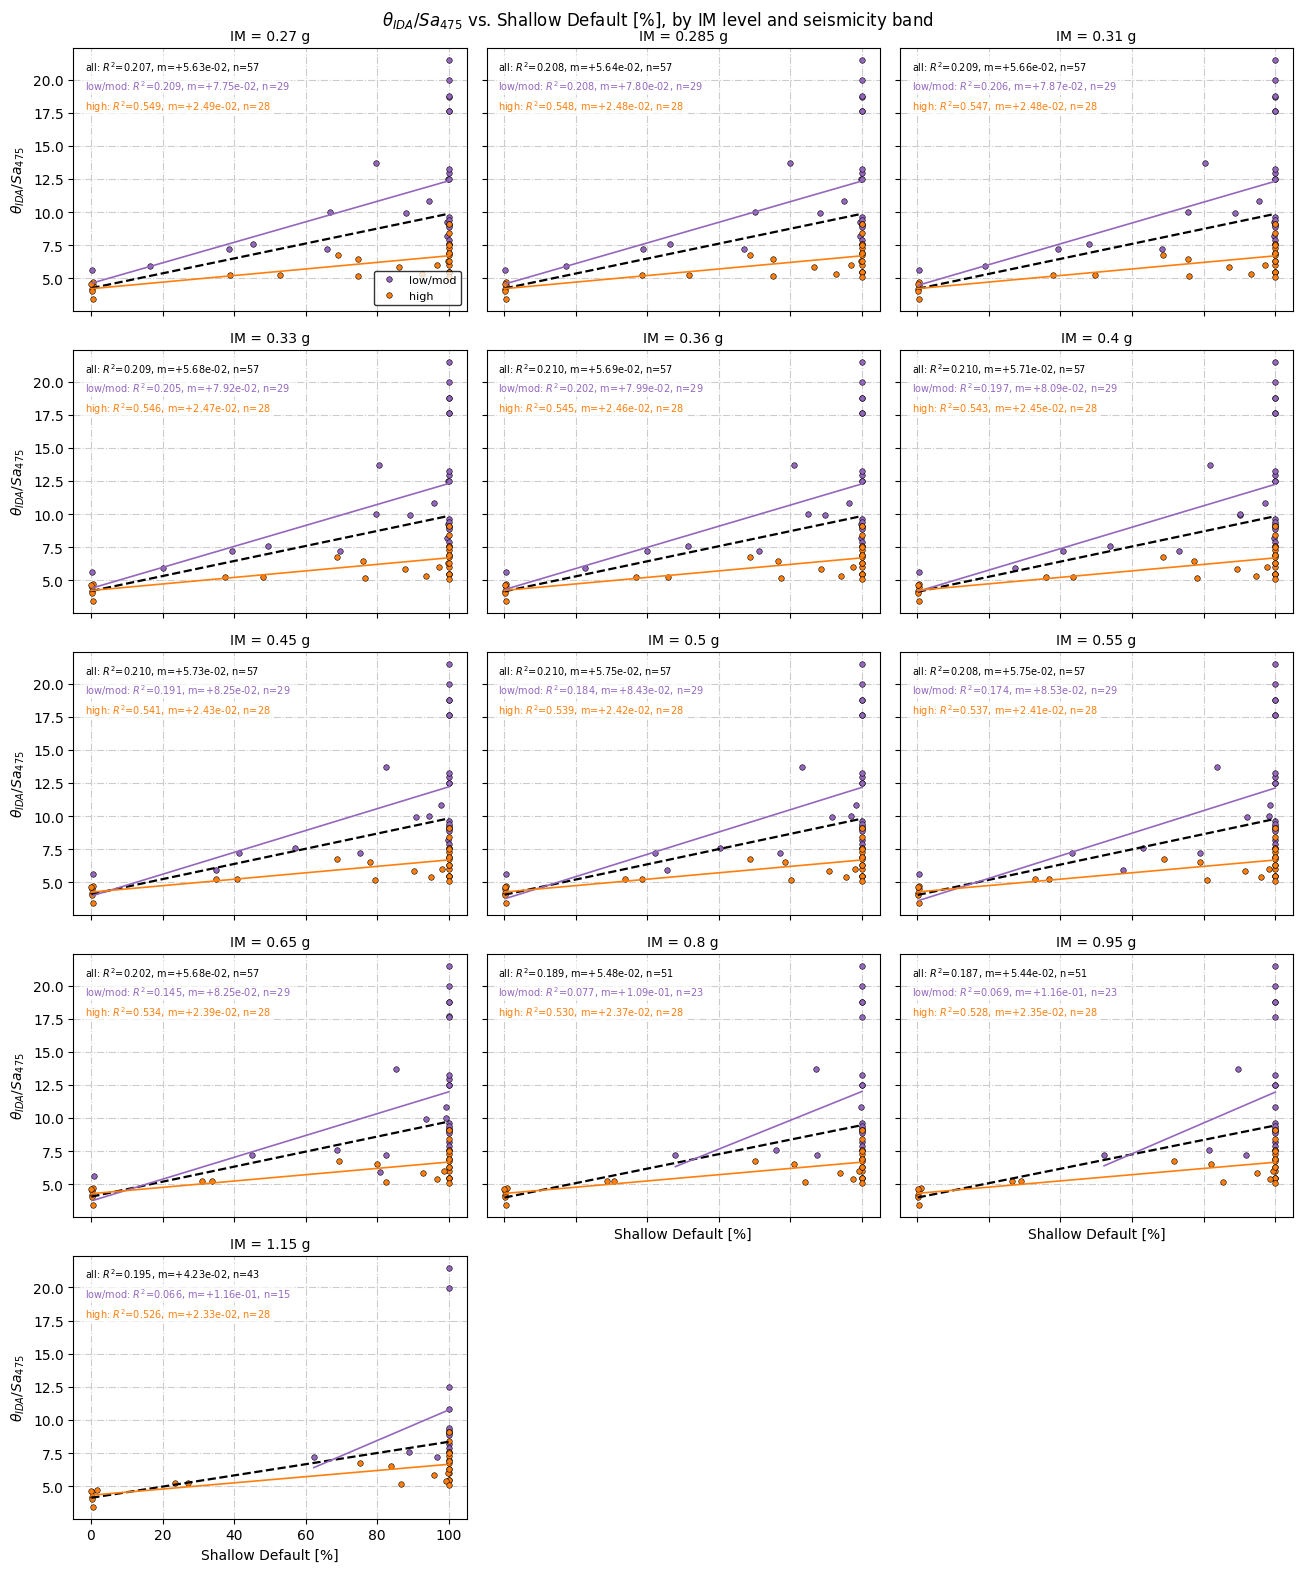

In [74]:
fig_tin, axs_tin, theta_ida_norm_fits = mih.plot_ratio_vs_proxy(
    pooled, disagg_stats, "theta_ida_norm", PROXY,
    ylabel=r"$\theta_{IDA}/Sa_{475}$")

theta_ida_norm_fits

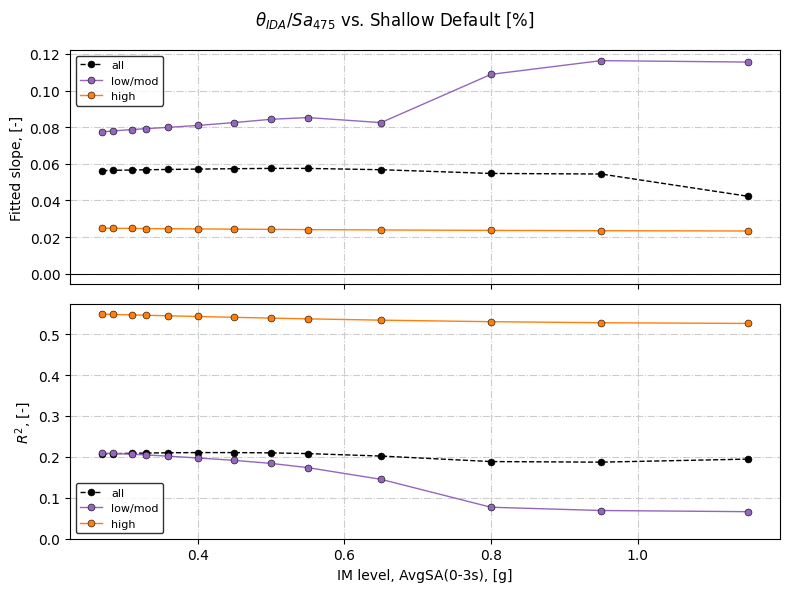

In [75]:
fig_tin_trend, axs_tin_trend = mih.plot_fit_trend_vs_iml(
    theta_ida_norm_fits, title=r"$\theta_{IDA}/Sa_{475}$ vs. " + PROXY)

##### At each site's own fragility quantiles

The grids above hold the IM level fixed across sites, which compares sites at
different points on their own fragility curves - 0.5 g is near-certain collapse for
one structure and barely damaging for another. Here the IM level is chosen *per
site* instead, as the disaggregation level closest to the 10%, 50% and 90%
quantile of that site's MSA fit, so every panel holds all 57 structures at a
comparable point on their own curve.

The disaggregation grid is coarse (13 levels, 0.27-1.15 g) and bounded, so the
match is not exact. `max_abs_gap` in the returned frame reports the worst residual
between the selected level and its target intensity, and should be read before the
fits are trusted - the 90% panel is the one most likely to run off the top of the
grid.

slope  intercept        r2  spearman_rho  \
variable       quantile group                                                 
beta_ratio     0.1      all     0.000433   1.047980  0.005391      0.048128   
               0.5      all     0.000575   1.036370  0.009499      0.074453   
               0.9      all     0.000759   1.021142  0.016451      0.081150   
               0.1      lowmod -0.002331   1.355739  0.072080     -0.290193   
               0.5      lowmod -0.002198   1.347459  0.059795     -0.240829   
...                                  ...        ...       ...           ...   
theta_ida_norm 0.5      lowmod  0.079095   4.337630  0.199156      0.437570   
               0.9      lowmod  0.080364   4.115698  0.185570      0.437570   
               0.1      high    0.024171   4.272132  0.538632      0.737940   
               0.5      high    0.023874   4.289679  0.534761      0.737940   
               0.9      high    0.023614   4.305100  0.531483      0.737940   

                                n_sites  median_imtl  max_abs_gap  
variable       quantile group                                      
beta_ratio     0.1      all          57        0.360     0.065996  
               0.5      all          57        0.450     0.070715  
               0.9      all          57        0.550     0.240978  
               0.1      lowmod       29        0.310     0.065996  
               0.5      lowmod       29        0.400     0.024859  
...                                 ...          ...          ...  
theta_ida_norm 0.5      lowmod       29        0.400     0.024859  
               0.9      lowmod       29        0.550     0.049435  
               0.1      high         28        0.425     0.045078  
               0.5      high         28        0.550     0.070715  
               0.9      high         28        0.800     0.240978  

[63 rows x 7 columns]

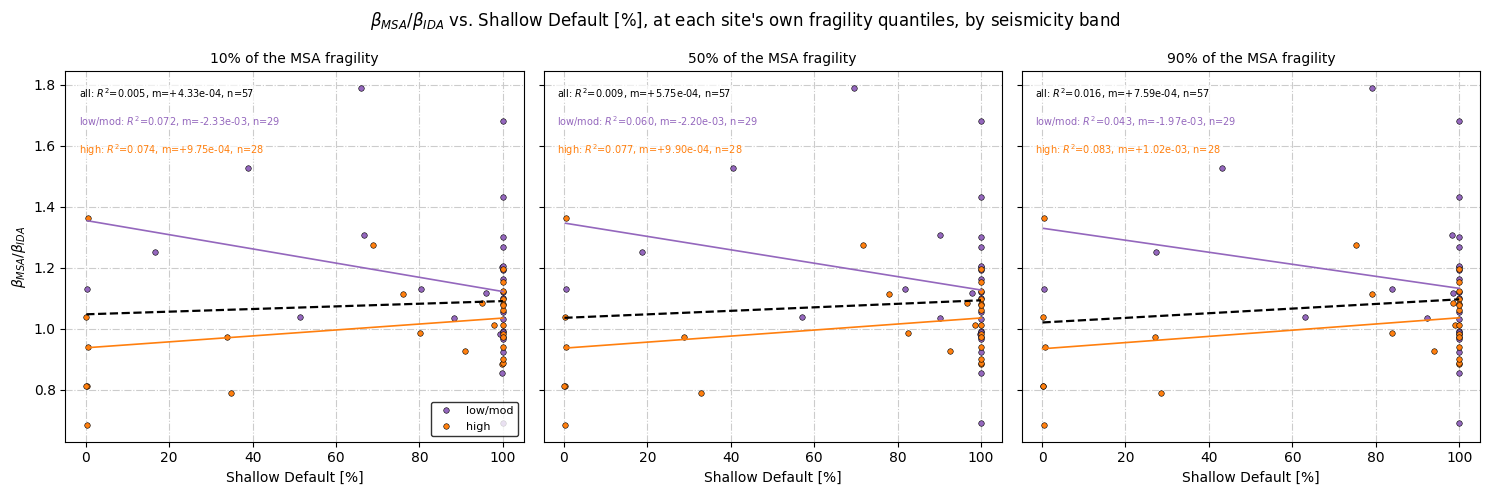

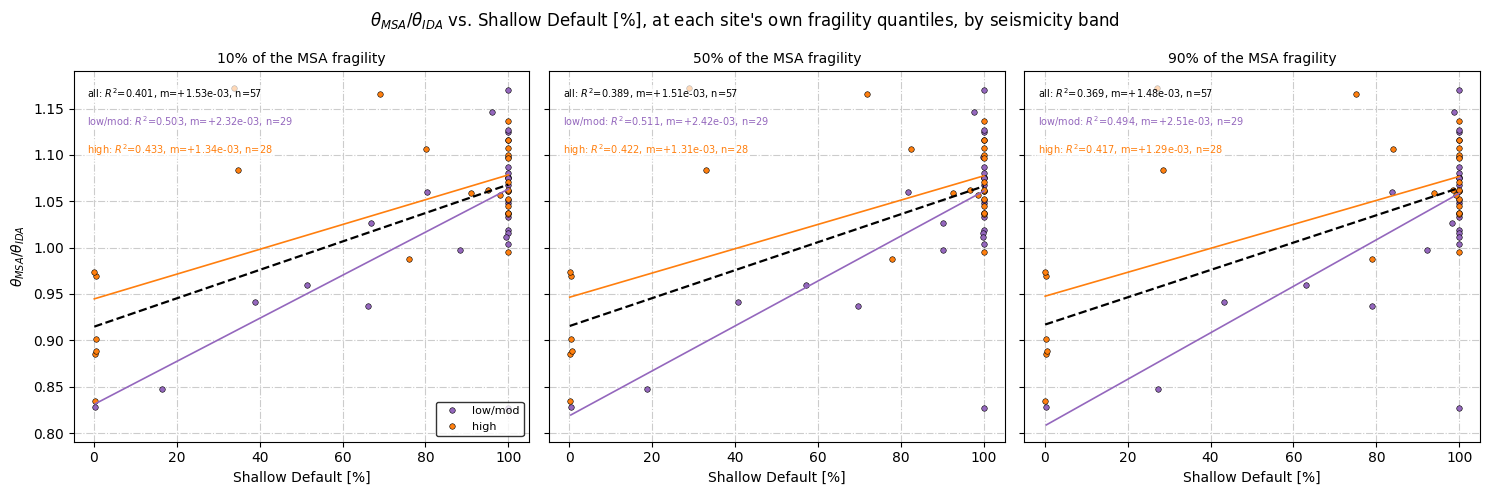

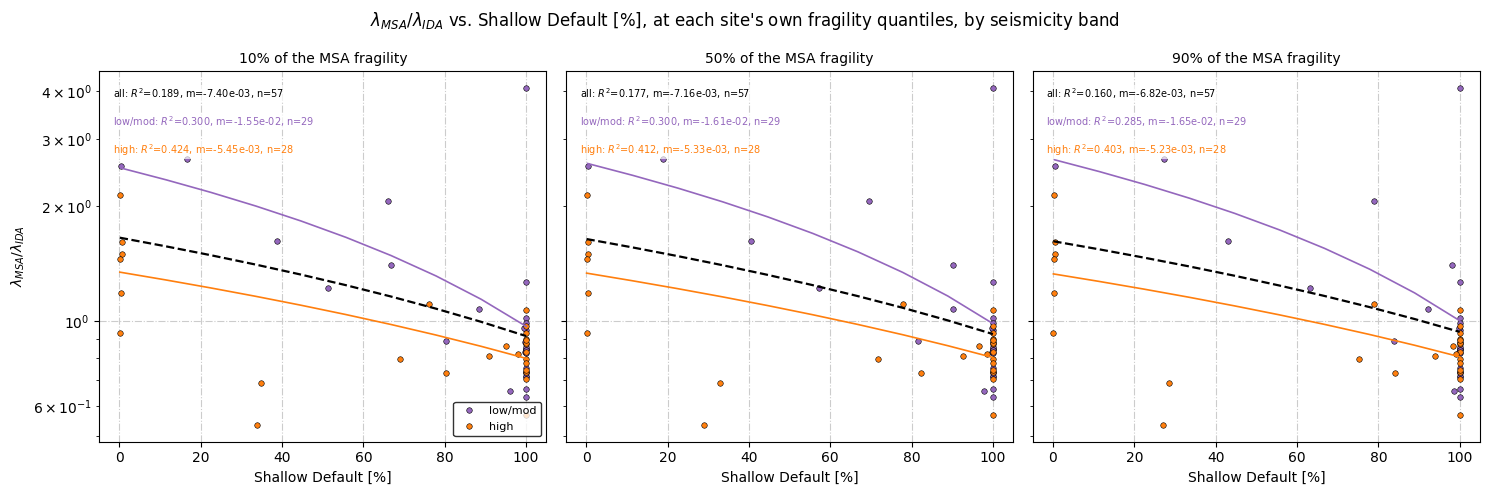

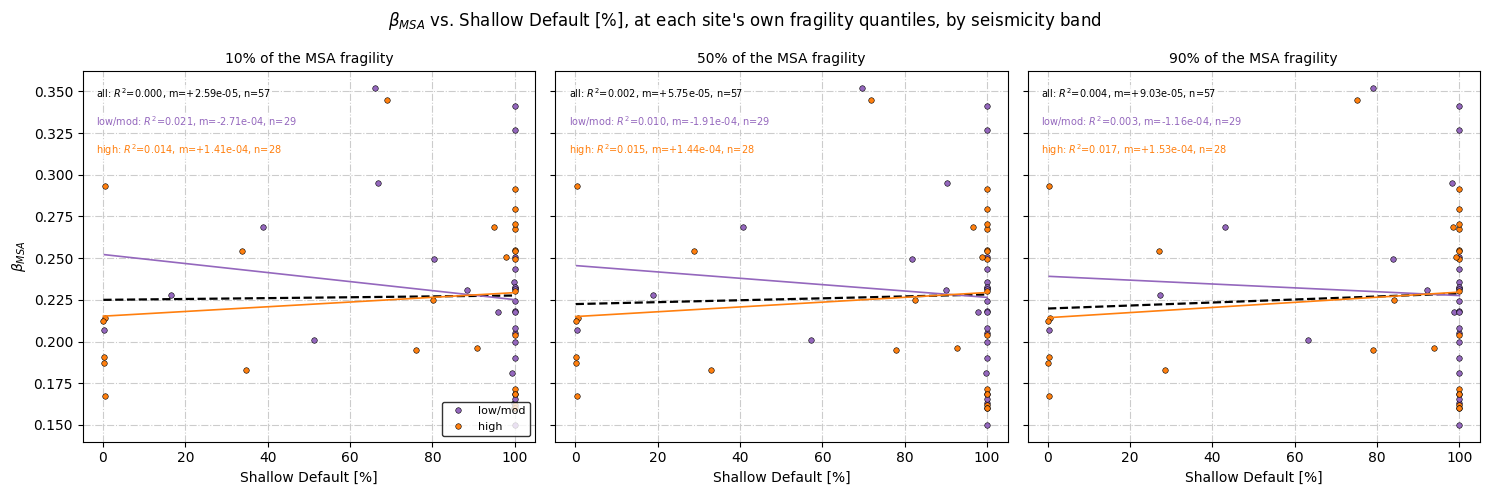

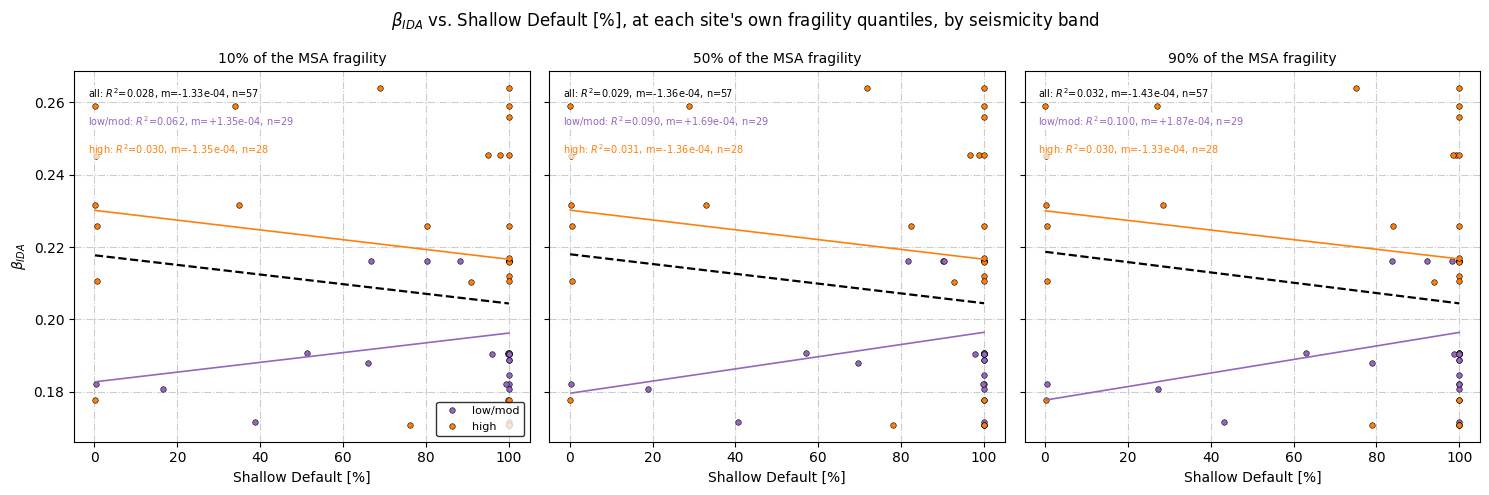

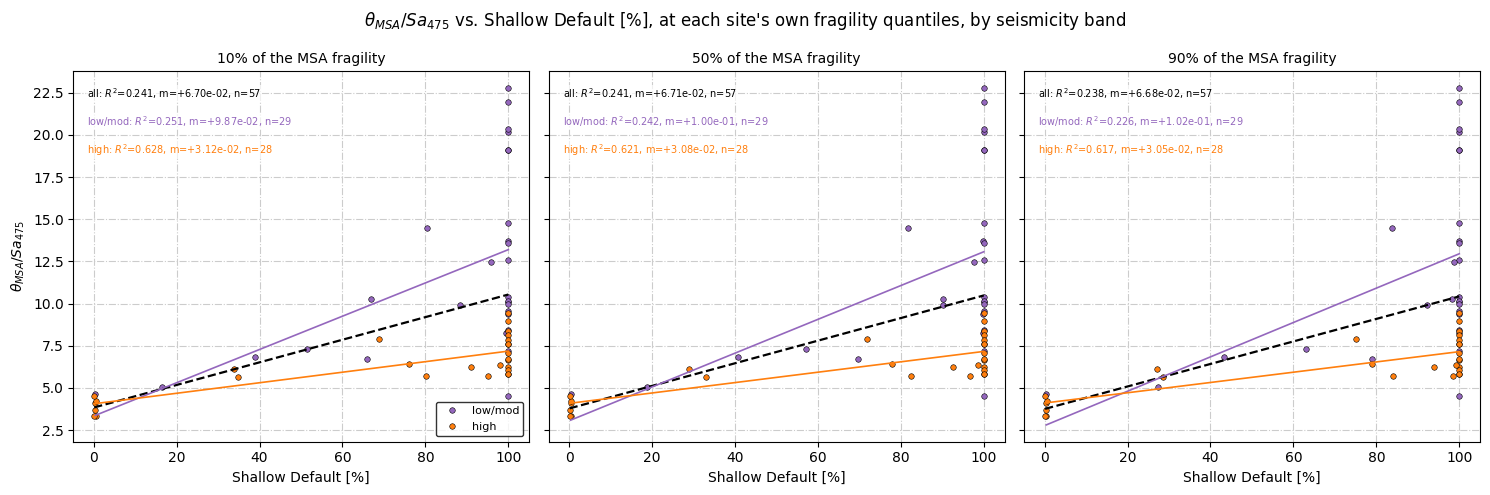

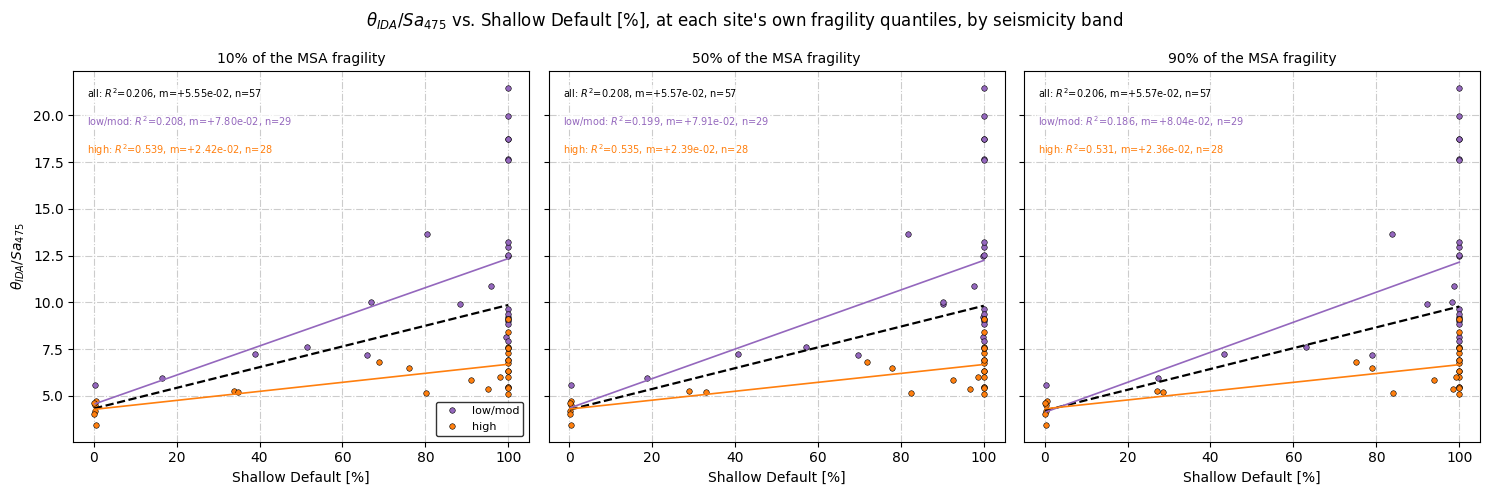

In [76]:
QUANTILES = (0.1, 0.5, 0.9)

QUANTILE_VARIABLES = {
    "beta_ratio": (r"$\beta_{MSA}/\beta_{IDA}$", False),
    "theta_ratio": (r"$\theta_{MSA}/\theta_{IDA}$", False),
    "mafc_ratio": (r"$\lambda_{MSA}/\lambda_{IDA}$", True),
    "beta_msa": (r"$\beta_{MSA}$", False),
    "beta_ida": (r"$\beta_{IDA}$", False),
    "theta_msa_norm": (r"$\theta_{MSA}/Sa_{475}$", False),
    "theta_ida_norm": (r"$\theta_{IDA}/Sa_{475}$", False),
}

quantile_figs, quantile_fits = {}, {}
for col, (label, log_y) in QUANTILE_VARIABLES.items():
    fig, axs, fits = mih.plot_ratio_vs_proxy_at_quantiles(
        pooled, disagg_stats, col, PROXY, quantiles=QUANTILES,
        ylabel=label, log_y=log_y)
    quantile_figs[col] = (fig, axs)
    quantile_fits[col] = fits

quantile_fits = pd.concat(quantile_fits, names=["variable"])
quantile_fits

The IM levels those quantiles actually selected, and how far the coarse grid
forced each match to stray from its target intensity.

In [77]:
picked = mih.select_disagg_at_fragility_quantiles(
    pooled, disagg_stats, PROXY, QUANTILES)

picked.groupby("quantile").agg(
    n=("tag", "size"),
    iml_target_median=("iml_target", "median"),
    imtl_min=("imtl", "min"),
    imtl_median=("imtl", "median"),
    imtl_max=("imtl", "max"),
    n_distinct_imtl=("imtl", "nunique"),
    abs_gap_median=("iml_gap", lambda g: g.abs().median()),
    abs_gap_max=("iml_gap", lambda g: g.abs().max()),
)

,n,iml_target_median,imtl_min,imtl_median,imtl_max,n_distinct_imtl,abs_gap_median,abs_gap_max
quantile,,,,,,,,
0.1,57,0.349120,0.27,0.36,0.65,10,0.010880,0.065996
0.5,57,0.455806,0.31,0.45,0.95,10,0.011874,0.070715
0.9,57,0.583894,0.40,0.55,1.15,8,0.023648,0.240978


##### Pooled against within-band: where the two disagree

A pooled fit whose sign is opposite to both bands, or whose $R^2$ exceeds both, is
measuring the contrast *between* the bands rather than any relationship inside
them. This table flags those cases across every variable and IM level.

In [78]:
grid_fits = {}
for col, (label, log_y) in QUANTILE_VARIABLES.items():
    _, _, fits = mih.plot_ratio_vs_proxy(
        pooled, disagg_stats, col, PROXY, ylabel=label, log_y=log_y)
    plt.close("all")          # the figures were already drawn above
    grid_fits[col] = fits

grid_fits = pd.concat(grid_fits, names=["variable"])

slopes = grid_fits["slope"].unstack("group")
flag = pd.DataFrame({
    "slope_all": slopes["all"],
    "slope_lowmod": slopes["lowmod"],
    "slope_high": slopes["high"],
    "r2_all": grid_fits["r2"].unstack("group")["all"],
    "sign_flip": (np.sign(slopes["all"]) != np.sign(slopes["lowmod"]))
                 | (np.sign(slopes["all"]) != np.sign(slopes["high"])),
})
flag[flag["sign_flip"]]

slope_all  slope_lowmod  slope_high    r2_all  sign_flip
variable   imtl                                                           
beta_ratio 0.270   0.000419     -0.002241    0.000984  0.004911       True
           0.285   0.000444     -0.002228    0.000984  0.005520       True
           0.310   0.000487     -0.002204    0.000984  0.006613       True
           0.330   0.000519     -0.002184    0.000984  0.007504       True
           0.360   0.000566     -0.002156    0.000984  0.008912       True
           0.400   0.000626     -0.002131    0.000984  0.010843       True
           0.450   0.000697     -0.002130    0.000985  0.013330       True
           0.500   0.000768     -0.002153    0.000985  0.016049       True
           0.550   0.000838     -0.002167    0.000986  0.018942       True
           0.650   0.000960     -0.002090    0.000989  0.024734       True
           0.800   0.001201     -0.007592    0.000996  0.040409       True
           0.950   0.001300     -0.008165    0.001008  0.047515       True
           1.150   0.001248     -0.011021    0.001032  0.054589       True
beta_msa   0.270   0.000035     -0.000256    0.000157  0.000631       True
           0.285   0.000039     -0.000245    0.000155  0.000785       True
           0.310   0.000046     -0.000227    0.000153  0.001080       True
           0.330   0.000051     -0.000213    0.000152  0.001326       True
           0.360   0.000058     -0.000194    0.000150  0.001717       True
           0.400   0.000066     -0.000173    0.000148  0.002209       True
           0.450   0.000074     -0.000156    0.000146  0.002724       True
           0.500   0.000080     -0.000148    0.000144  0.003148       True
           0.550   0.000085     -0.000142    0.000143  0.003519       True
           0.650   0.000092     -0.000129    0.000142  0.004144       True
           0.800   0.000060     -0.001107    0.000142  0.001824       True
           0.950   0.000075     -0.001141    0.000145  0.002866       True
           1.150   0.000068     -0.001528    0.000152  0.002707       True
beta_ida   0.270  -0.000122      0.000133   -0.000123  0.023069       True
           0.285  -0.000123      0.000138   -0.000124  0.023717       True
           0.310  -0.000126      0.000146   -0.000126  0.024790       True
           0.330  -0.000129      0.000152   -0.000128  0.025644       True
           0.360  -0.000132      0.000161   -0.000129  0.026973       True
           0.400  -0.000137      0.000171   -0.000131  0.028971       True
           0.450  -0.000145      0.000182   -0.000133  0.031930       True
           0.500  -0.000153      0.000190   -0.000135  0.035547       True
           0.550  -0.000162      0.000196   -0.000136  0.039471       True
           0.650  -0.000177      0.000195   -0.000137  0.047099       True
           0.800  -0.000253      0.000253   -0.000138  0.088351       True
           0.950  -0.000258      0.000301   -0.000138  0.092221       True
           1.150  -0.000252      0.000422   -0.000137  0.089114       True

#### Proxy 2: the hazard level itself

`Shallow Default [%]` describes *where the shaking comes from*. This proxy describes
*how strong it is*: the AvgSA(0-3s) the site's own mean hazard curve reaches at the
475, 2475 and 4975-year return periods, interpolated log-log from the numerical
curves in `hcs` (mafe = 1/RTP; the zero-mafe tail of each curve is dropped first,
and a return period outside a curve's range would give NaN rather than clamp).

This is much closer to what actually drove each design, so it is the natural
control on the tectonic-composition results above - and it separates the two
seismicity bands almost perfectly by construction, which is exactly why the band
split matters here too.

In [79]:
RETURN_PERIODS = (475, 2475, 4975)
HAZ_PROXY = "AvgSA(0-3s) [g]"

hazard_levels = mih.site_hazard_at_return_periods(
    hcs, sorted(pooled["site_id"].unique()), RETURN_PERIODS)

hazard_levels.describe()

,475,2475,4975
count,57.000000,57.000000,57.000000
mean,0.070700,0.147356,0.191829
std,0.040081,0.076209,0.097133
min,0.018318,0.043121,0.055389
25%,0.039457,0.078586,0.103157
50%,0.059800,0.124152,0.177031
75%,0.106034,0.212171,0.270857
max,0.178677,0.311793,0.379741


slope  intercept        r2  \
variable    return_period group                                    
beta_ratio  475           all     -1.119920   1.161249  0.046200   
            2475          all     -0.675892   1.181667  0.060835   
            4975          all     -0.543292   1.186290  0.063854   
            475           lowmod   5.537516   0.930723  0.127026   
            2475          lowmod   2.261610   0.967483  0.068070   
            4975          lowmod   1.431481   0.999493  0.043843   
            475           high    -0.220010   1.029507  0.002390   
            2475          high     0.180105   0.968449  0.003152   
            4975          high     0.277196   0.929892  0.010754   
theta_ratio 475           all     -0.343350   1.059528  0.025822   
            2475          all     -0.058237   1.043835  0.002686   
            4975          all     -0.006914   1.036580  0.000062   
            475           lowmod  -4.115949   1.197734  0.493200   
            2475          lowmod  -1.842402   1.183756  0.317478   
            4975          lowmod  -1.217993   1.163294  0.223069   
            475           high    -0.393401   1.079397  0.023824   
            2475          high     0.069425   1.024363  0.001460   
            4975          high     0.208311   0.981258  0.018935   
mafc_ratio  475           all      0.869780   1.010274  0.003354   
            2475          all     -0.399059   1.130571  0.002553   
            4975          all     -0.559151   1.179028  0.008142   
            475           lowmod  33.240321  -0.162050  0.430298   
            2475          lowmod  14.022260   0.021697  0.246001   
            4975          lowmod   8.976722   0.209190  0.162085   
            475           high     2.121736   0.741810  0.040903   
            2475          high     0.025082   0.953000  0.000011   
            4975          high    -0.605524   1.126926  0.009443   
beta_msa    475           all      0.167020   0.215226  0.018603   
            2475          all      0.054286   0.219035  0.007105   
            4975          all      0.032802   0.220742  0.004214   
            475           lowmod   0.512535   0.208104  0.023872   
            2475          lowmod   0.042008   0.225342  0.000515   
            4975          lowmod  -0.058239   0.235123  0.001592   
            475           high     0.507762   0.173362  0.117345   
            2475          high     0.407193   0.137917  0.148543   
            4975          high     0.335889   0.131693  0.145553   
beta_ida    475           all      0.415967   0.177842  0.354771   
            2475          all      0.200130   0.177761  0.296885   
            4975          all      0.148849   0.178698  0.266793   
            475           lowmod  -0.533328   0.215926  0.300411   
            2475          lowmod  -0.349687   0.223290  0.414905   
            4975          lowmod  -0.289835   0.225758  0.458243   
            475           high     0.604196   0.158919  0.383028   
            2475          high     0.398227   0.135238  0.327524   
            4975          high     0.295444   0.138351  0.259604   

                                  spearman_rho  n_sites  
variable    return_period group                          
beta_ratio  475           all        -0.243778       57  
            2475          all        -0.274890       57  
            4975          all        -0.272686       57  
            475           lowmod      0.229064       29  
            2475          lowmod      0.167980       29  
            4975          lowmod      0.102956       29  
            475           high       -0.131363       28  
            2475          high       -0.043788       28  
            4975          high        0.033935       28  
theta_ratio 475           all        -0.163858       57  
            2475          all        -0.057947       57  
            4975          all        -0.044205       57  
            475           low

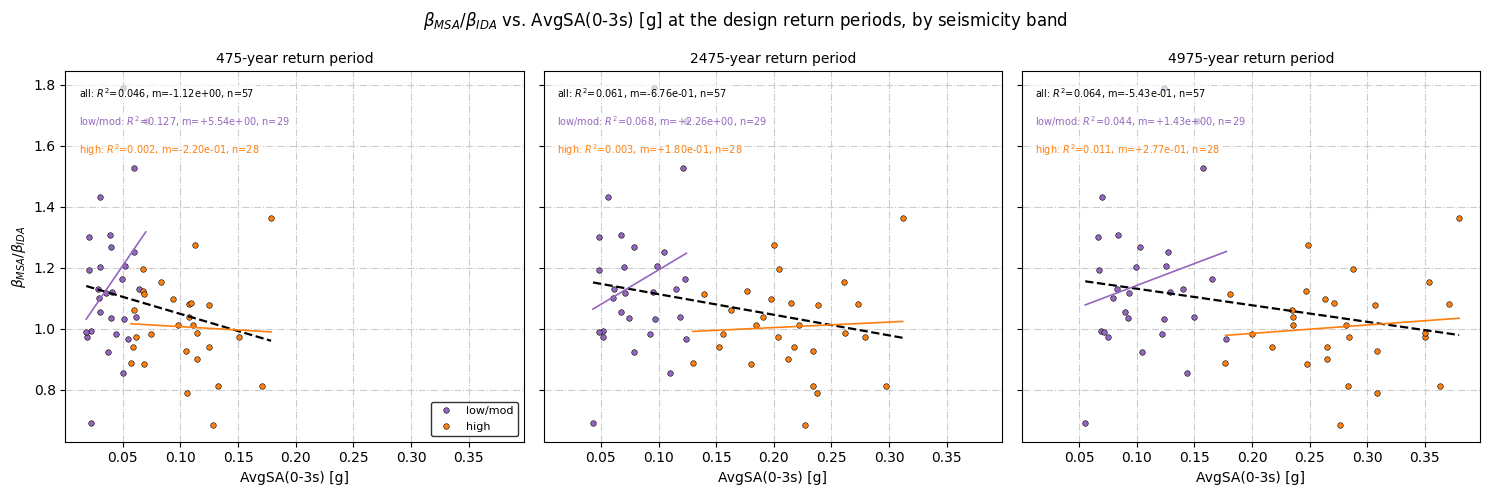

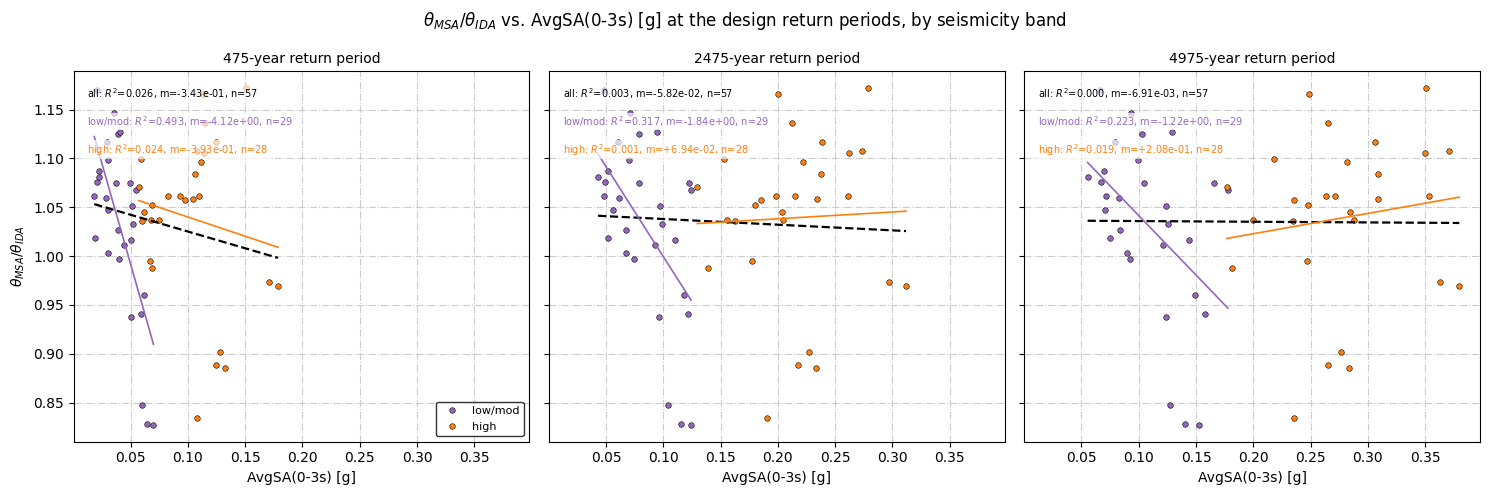

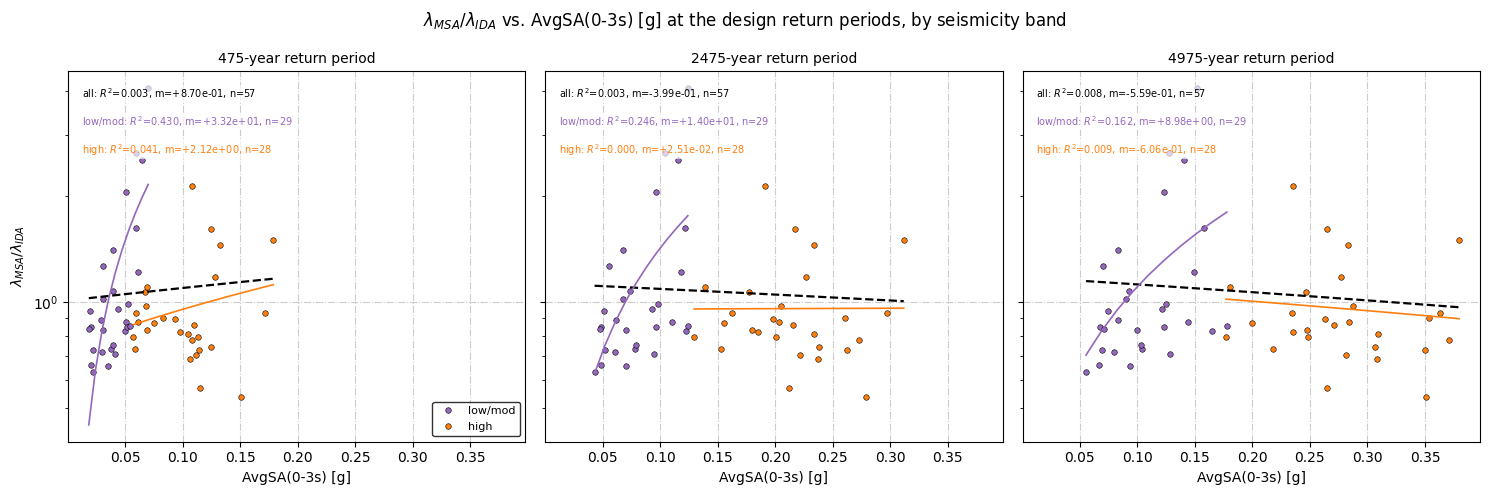

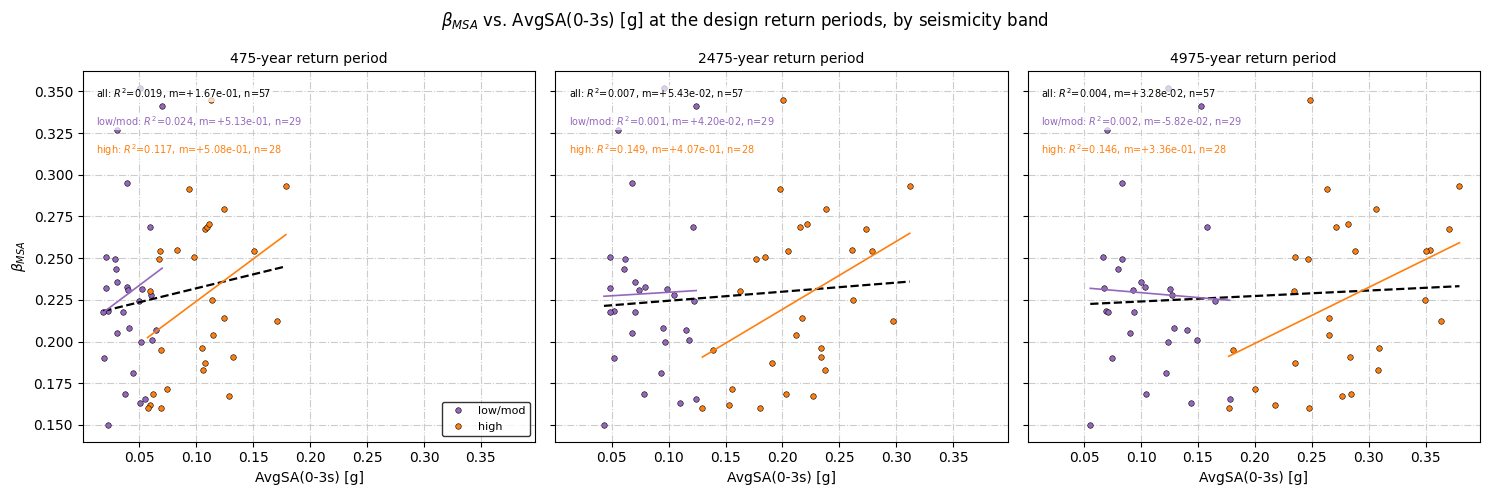

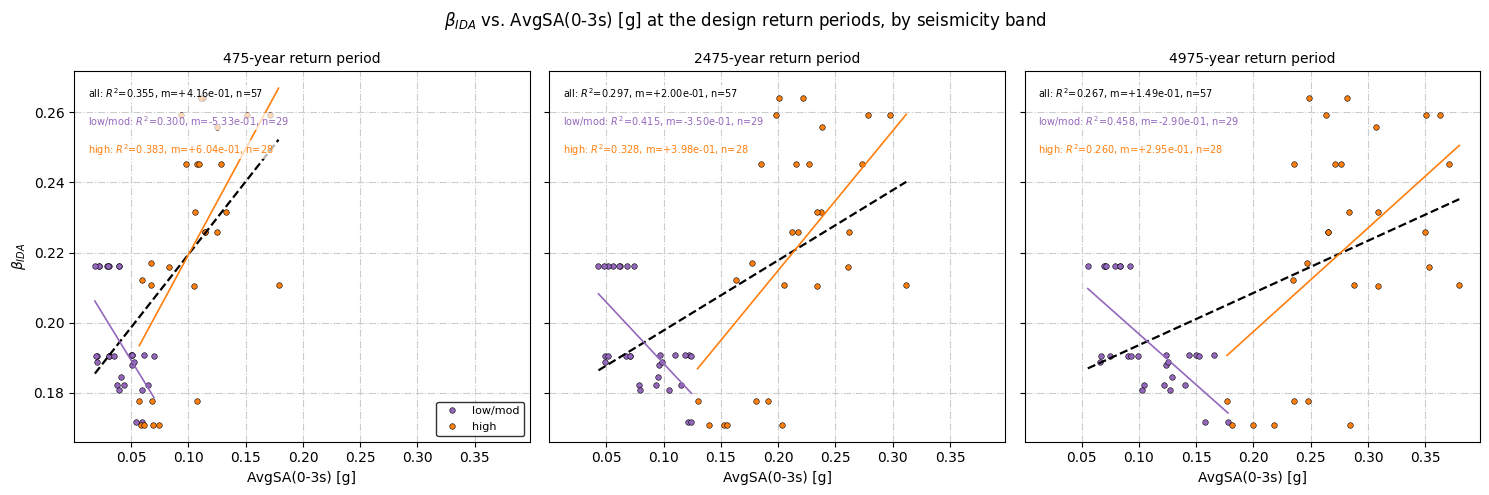

In [80]:
# The design-normalised medians are excluded here on purpose: they are divided by
# the 475-year hazard level, so regressing them on the hazard level would measure
# the shared denominator rather than anything structural.
# `mih.plot_ratio_vs_hazard_level` refuses these columns outright.
HAZ_VARIABLES = {k: v for k, v in QUANTILE_VARIABLES.items()
                 if k not in mih.DESIGN_NORMALISED_COLUMNS}

hazard_figs, hazard_fits = {}, {}
for col, (label, log_y) in HAZ_VARIABLES.items():
    fig, axs, fits = mih.plot_ratio_vs_hazard_level(
        pooled, hcs, disagg_stats, col, RETURN_PERIODS, HAZ_PROXY,
        ylabel=label, log_y=log_y)
    hazard_figs[col] = (fig, axs)
    hazard_fits[col] = fits

hazard_fits = pd.concat(hazard_fits, names=["variable"])
hazard_fits

Ranked by how much each variable actually responds to the hazard level, within
band rather than pooled.

In [81]:
(hazard_fits.drop("all", level="group")["r2"]
 .unstack("group").sort_values("high", ascending=False))

group                        lowmod      high
variable    return_period                    
beta_ida    475            0.300411  0.383028
            2475           0.414905  0.327524
            4975           0.458243  0.259604
beta_msa    2475           0.000515  0.148543
            4975           0.001592  0.145553
            475            0.023872  0.117345
mafc_ratio  475            0.430298  0.040903
theta_ratio 475            0.493200  0.023824
            4975           0.223069  0.018935
beta_ratio  4975           0.043843  0.010754
mafc_ratio  4975           0.162085  0.009443
beta_ratio  2475           0.068070  0.003152
            475            0.127026  0.002390
theta_ratio 2475           0.317478  0.001460
mafc_ratio  2475           0.246001  0.000011

##### Why `theta/Sa_475` is absent from the charts above

`Sa_475` is the denominator of `theta_msa_norm` and `theta_ida_norm` and the hazard
level is the abscissa, so the two are algebraically linked and a strong negative
correlation appears whether or not `theta` says anything about the hazard. Using a
longer return period on the abscissa does not escape it - the hazard levels are
correlated at r = 0.90-0.94 across these sites - so `mih.plot_ratio_vs_hazard_level`
refuses these two columns and they are excluded from the loop above. Their
`Shallow Default [%]` regressions share no term with the response and are unaffected.
